The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Training Temporal GRU Autoencoder for Imputation...
139/139 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Training Survival GRU...
------------------------------
C-Index: 0.8539
Sensitivity (Recall): 0.8508 [0.816, 0.880]
Specificity         : 0.8832 [0.873, 0.893]
PPV (Precision)     : 0.4666 [0.434, 0.500]
NPV                 : 0.9801 [0.975, 0.984]
Balanced Accuracy   : 0.8670 [0.857, 0.877]

Metric                              | Value      | Category
-----------------------------------------------------------------
Alerts per 100 Patient-Visits       | 18.3       | Clinical Burden
Proportion of Visits in Alert       | 18.31%     | Alarm Density
Median TIW (True Positives)         | 181.0 days | Lead Time
Median TIW (False Positives)        | 59.0 days  | Noise Duration


Slope: 0.7086 | Intercept: -0.1730 | R-sq: 0.7479


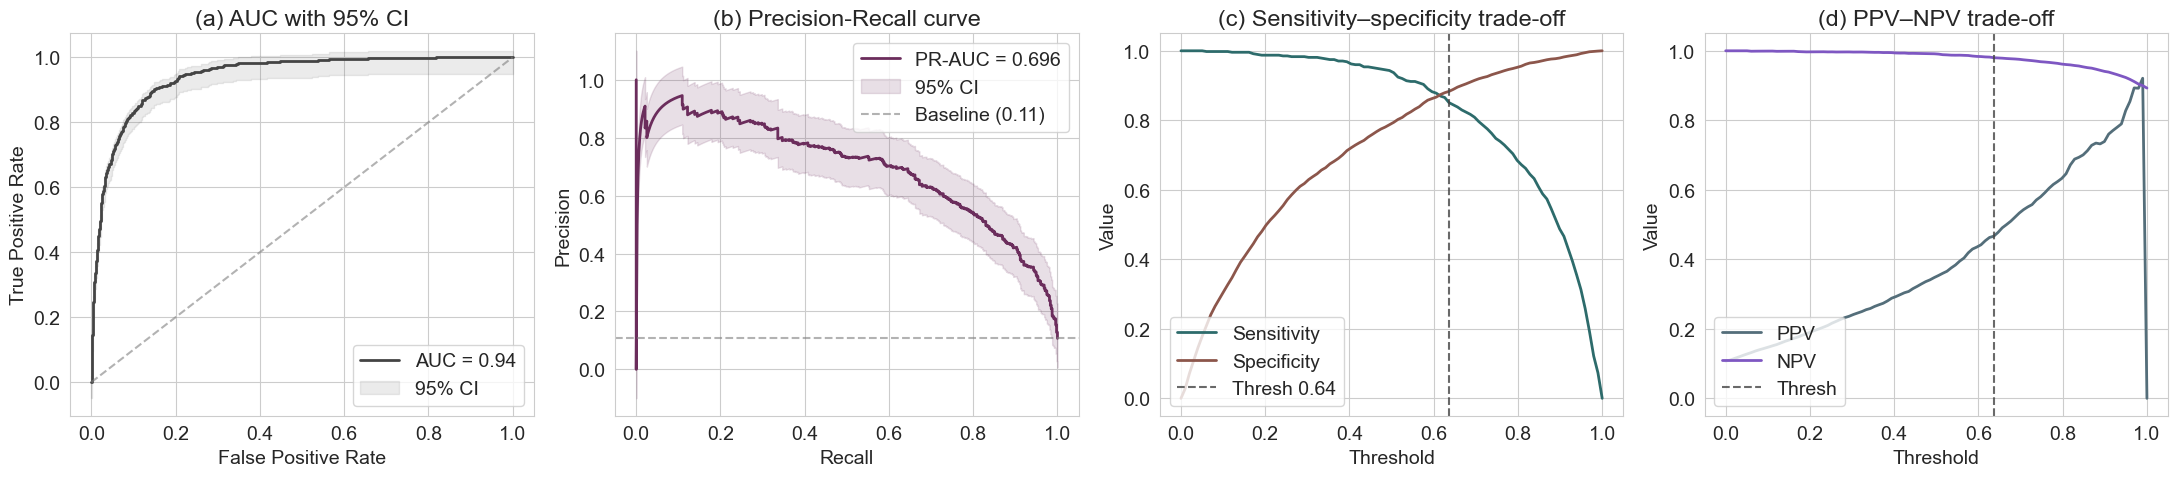

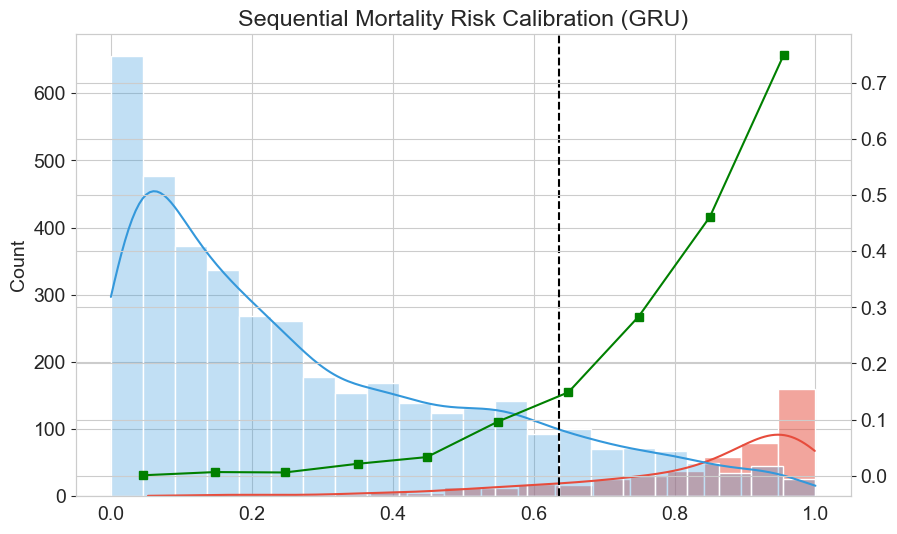

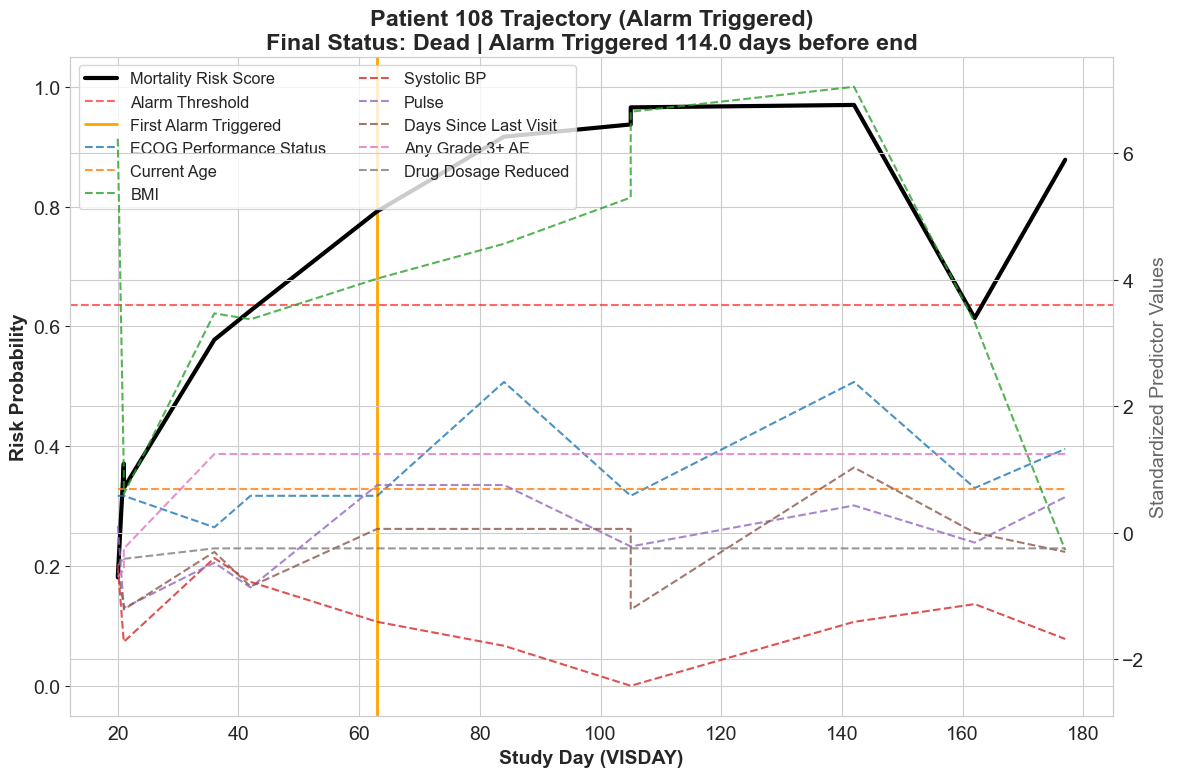

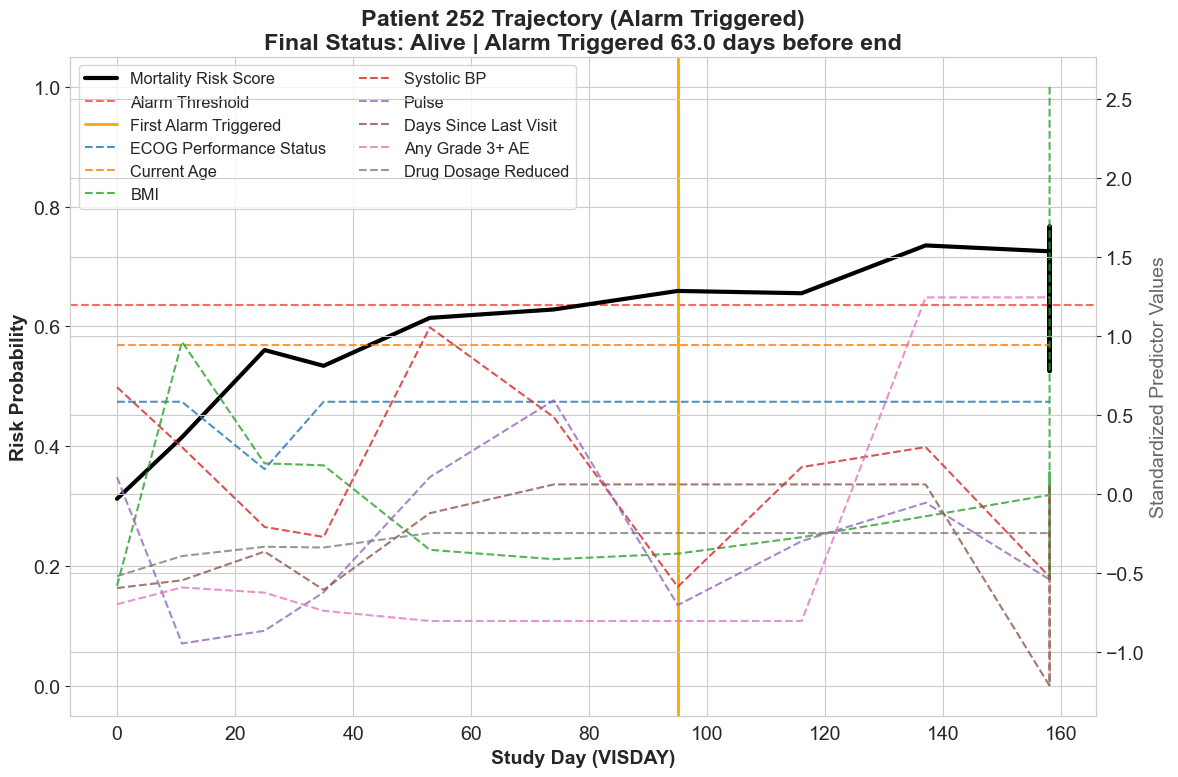

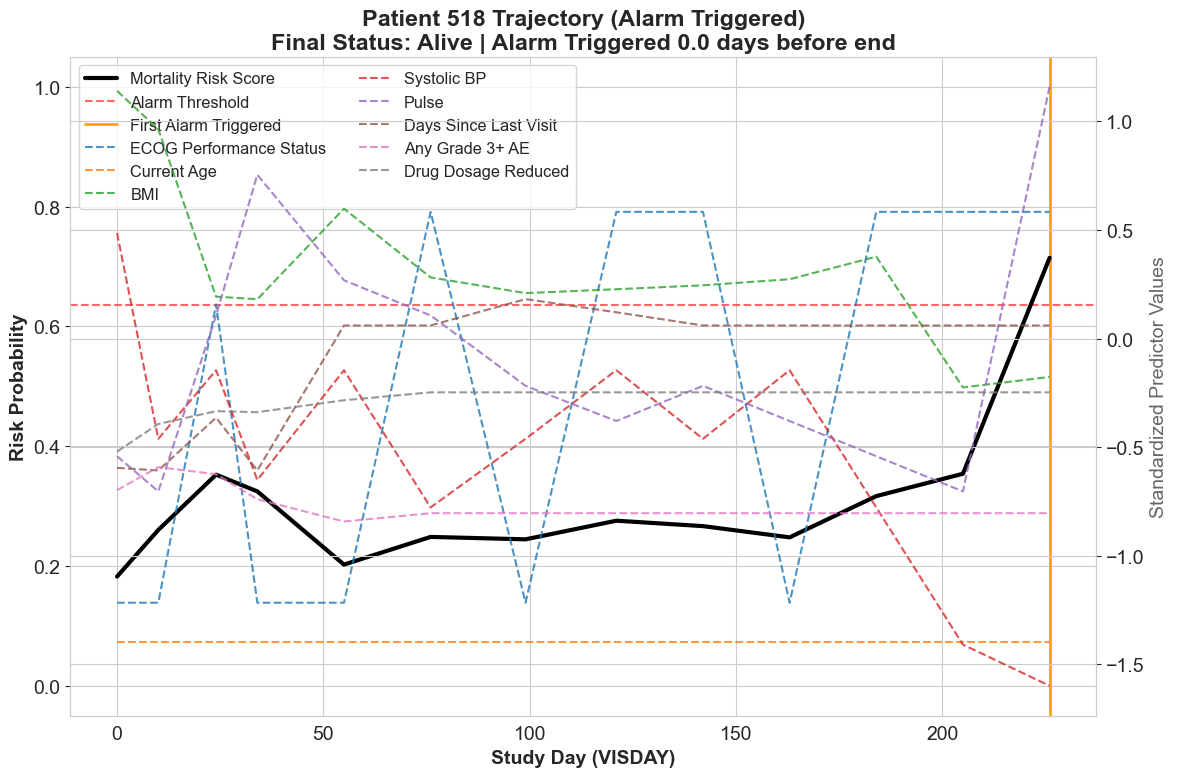

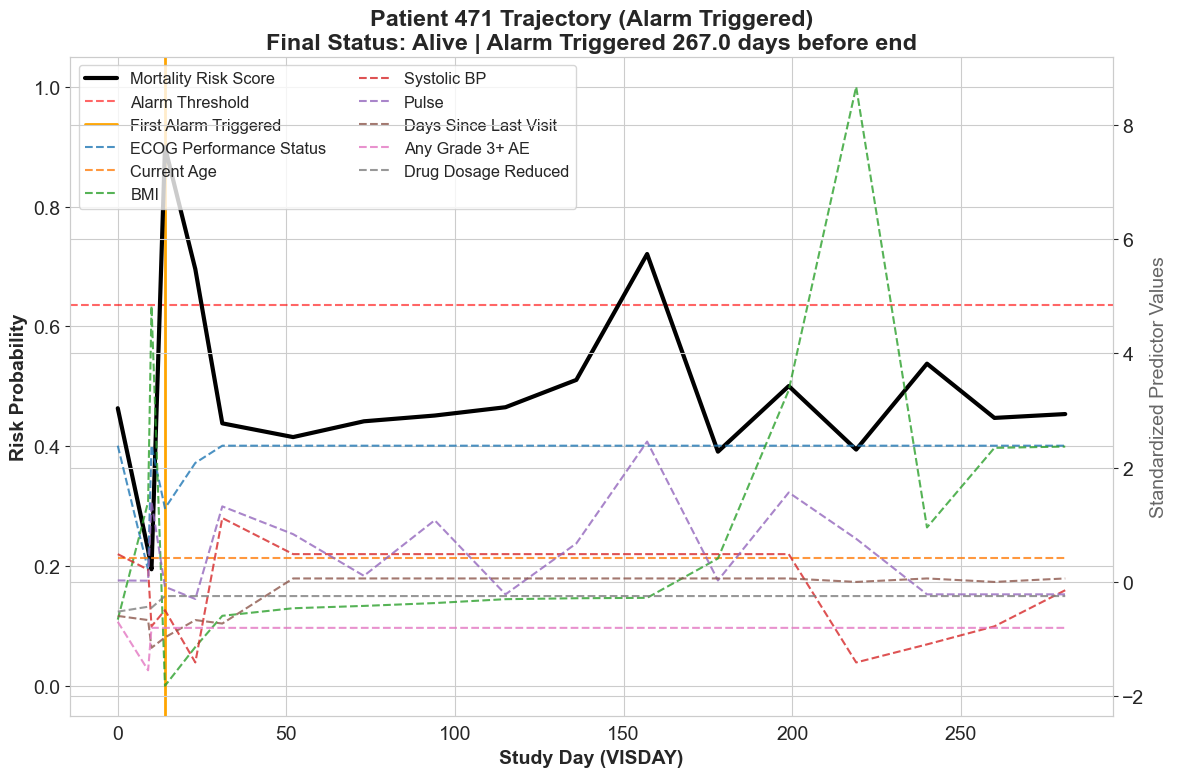

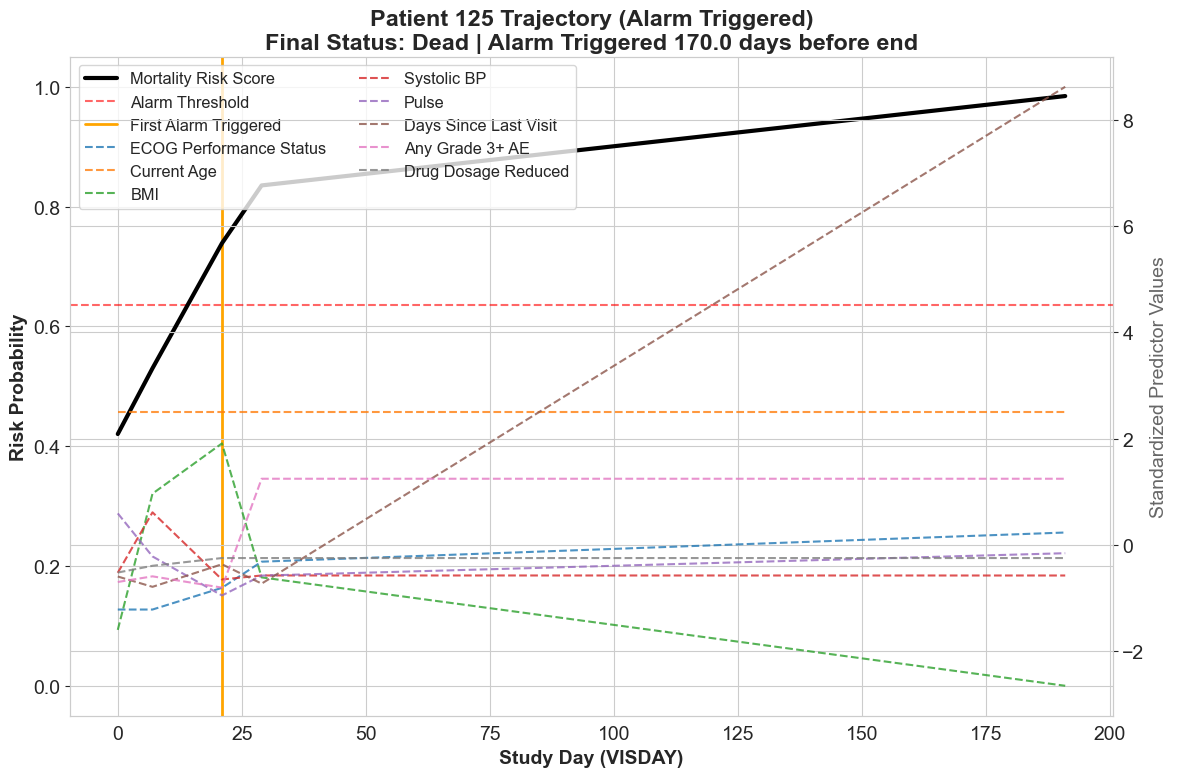

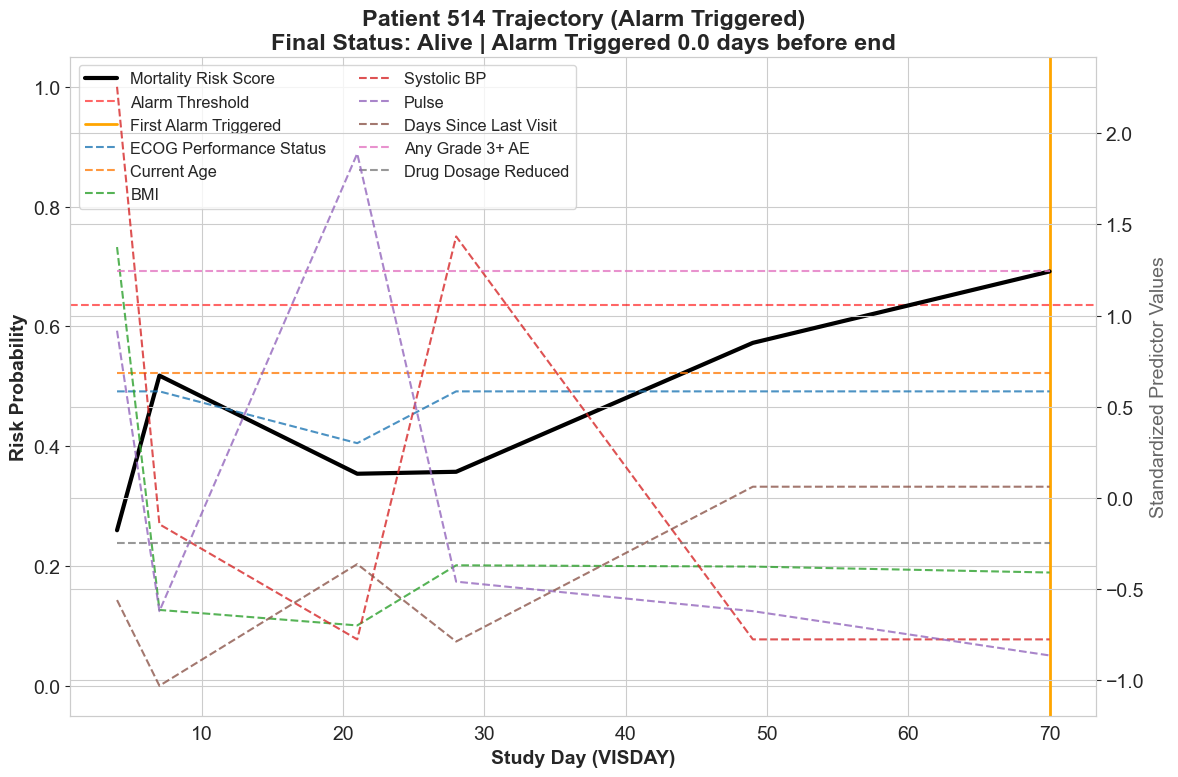

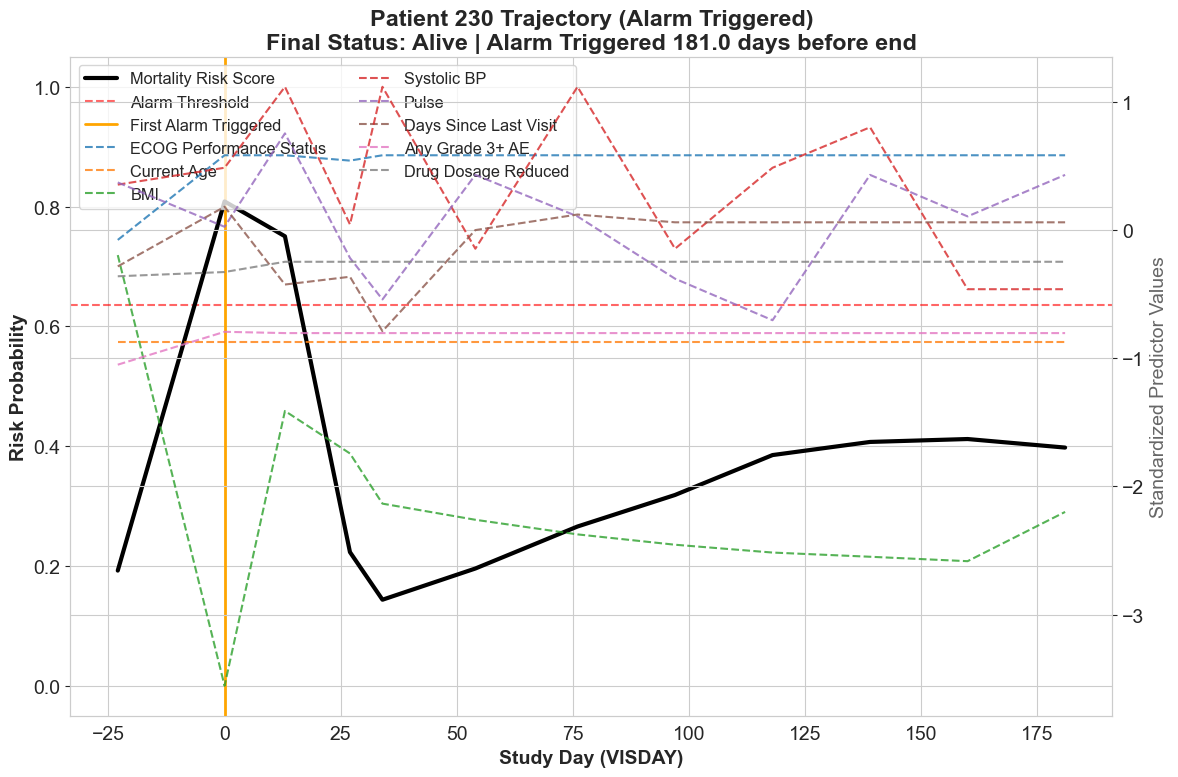

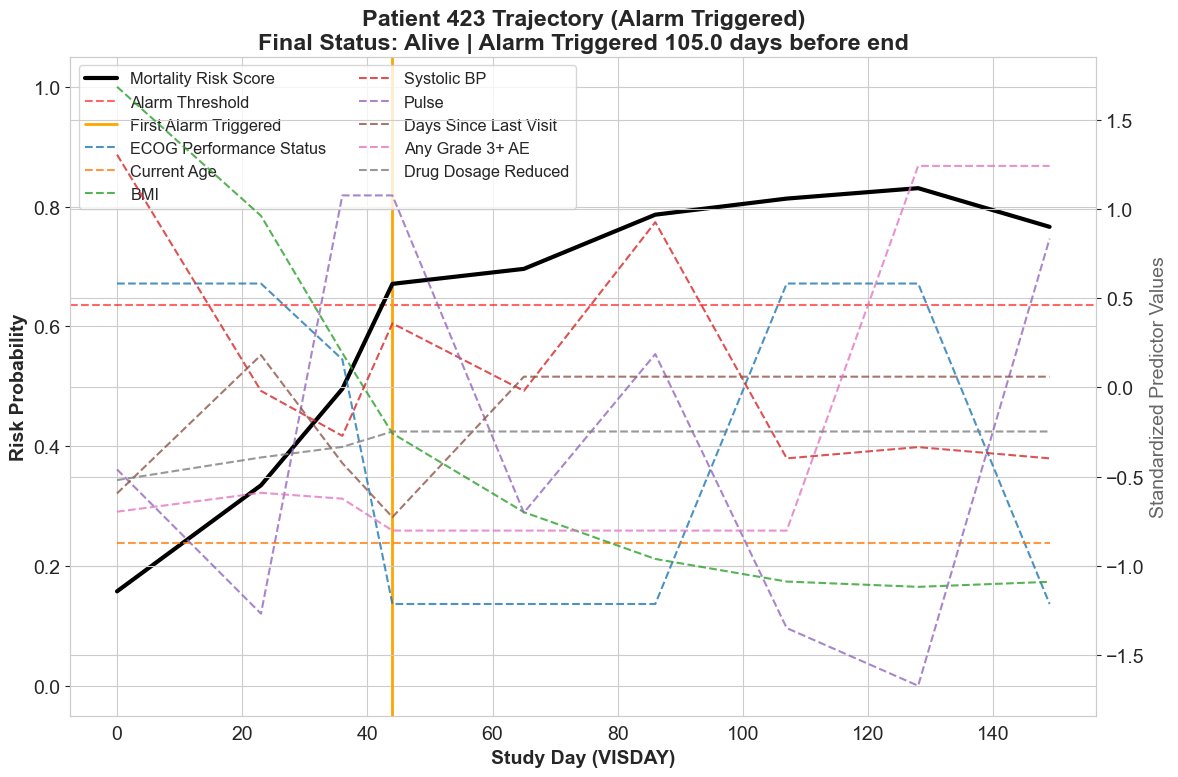

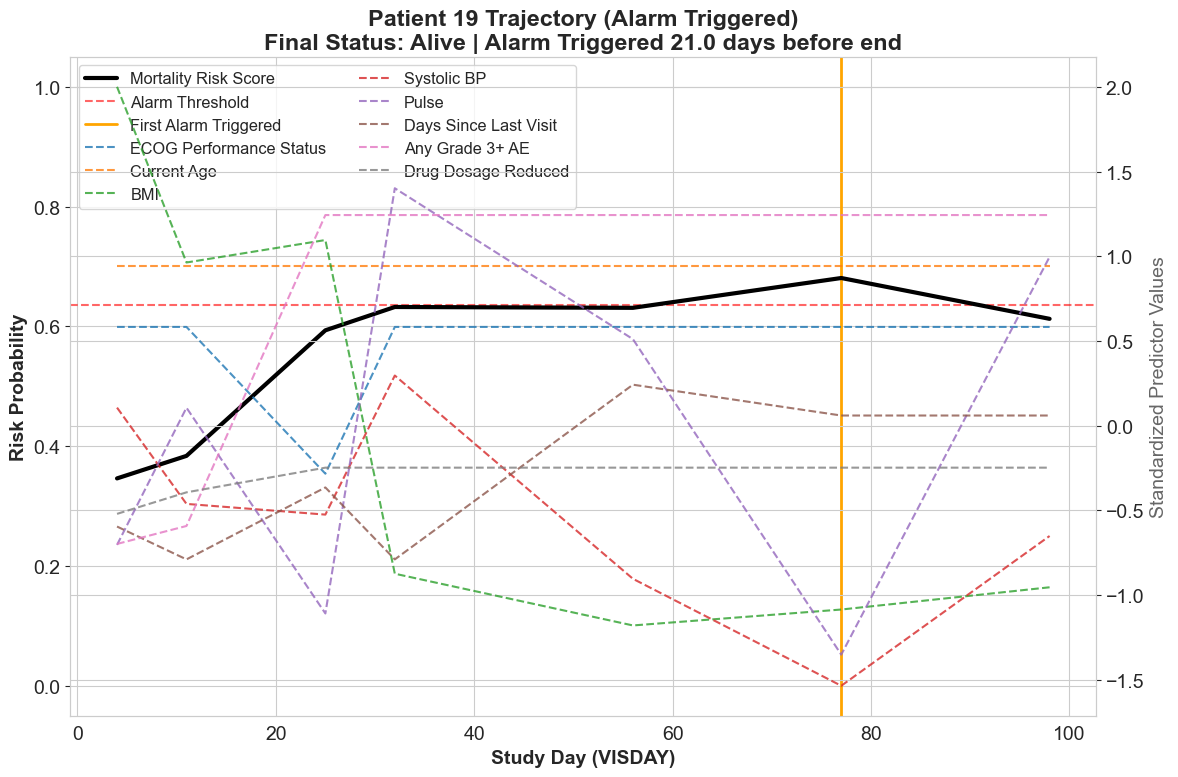

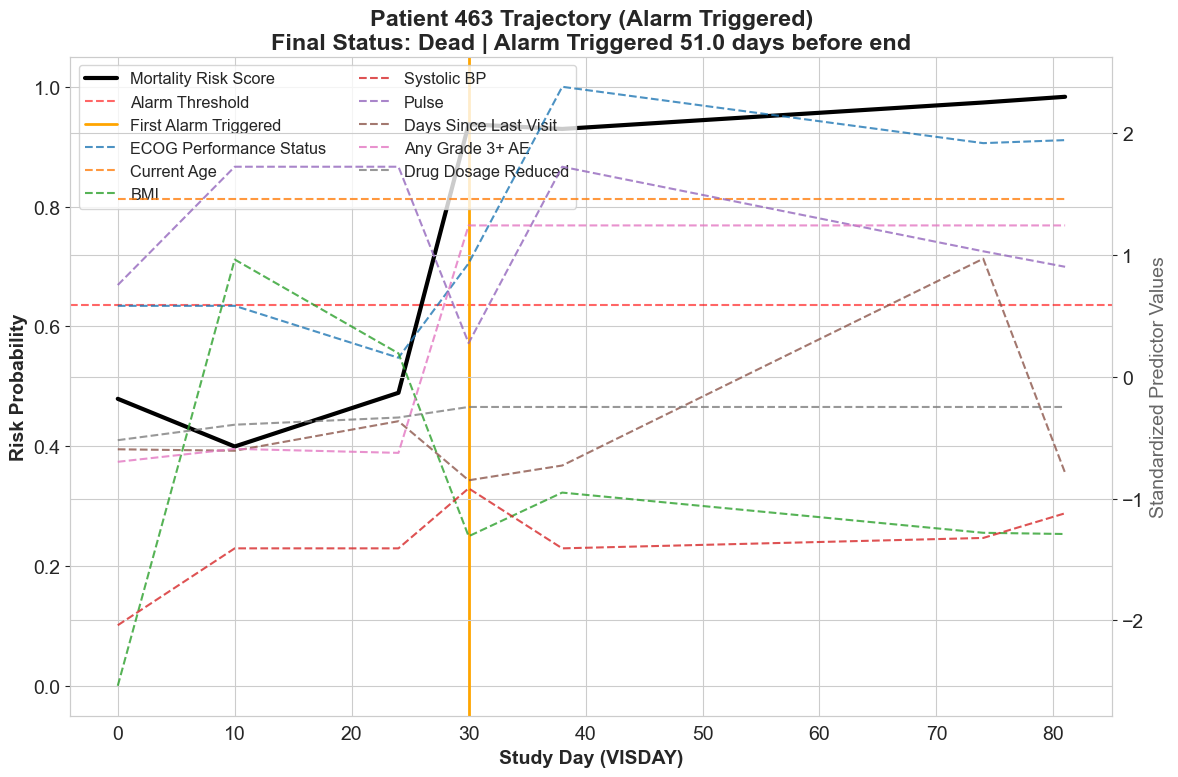

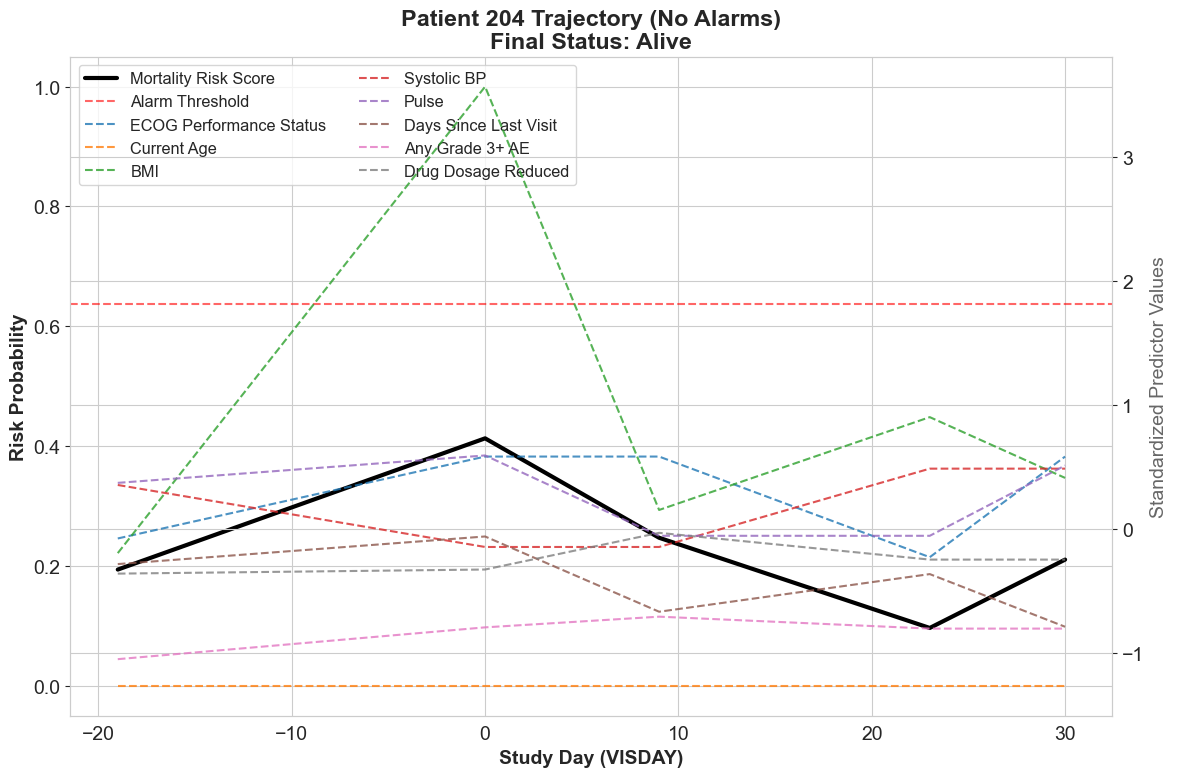

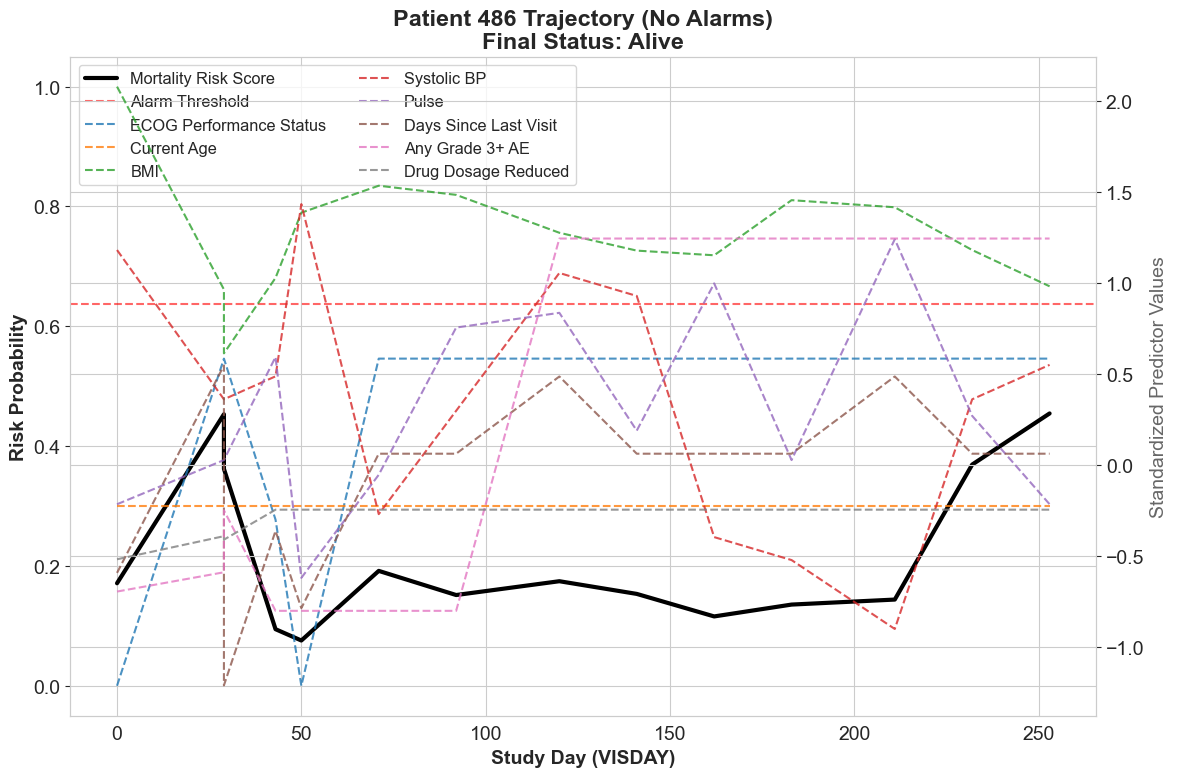

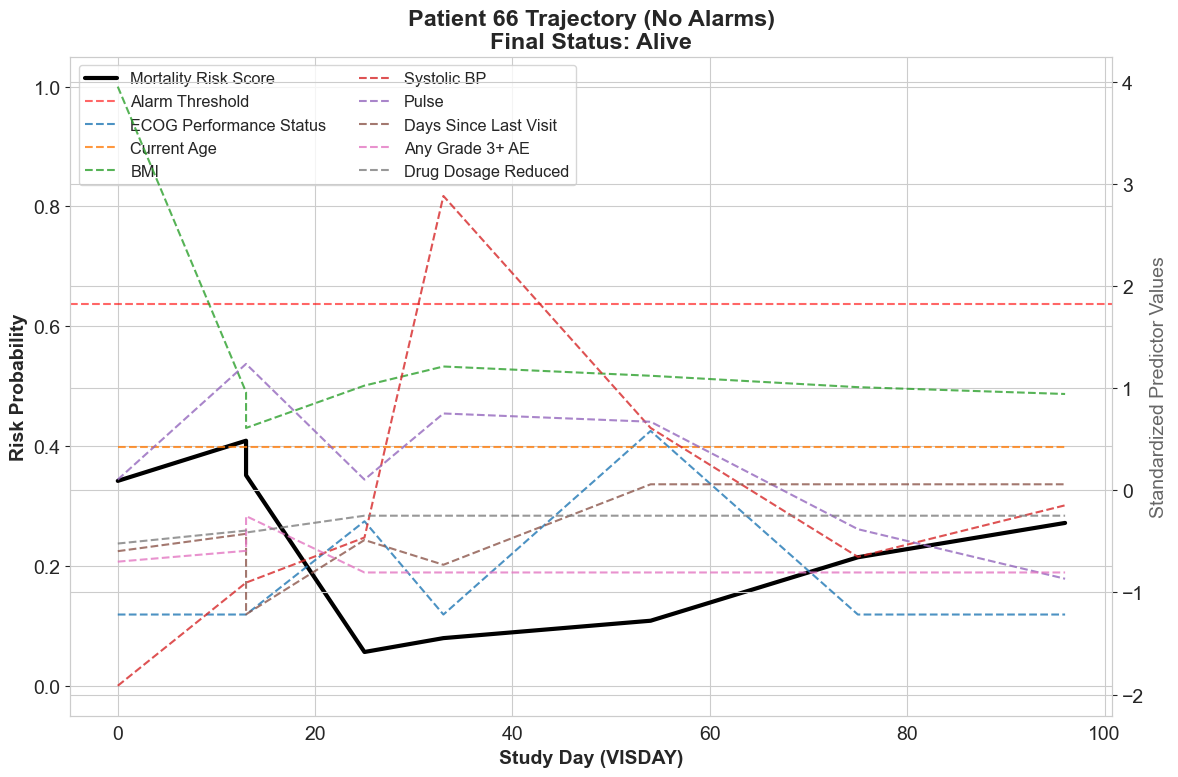

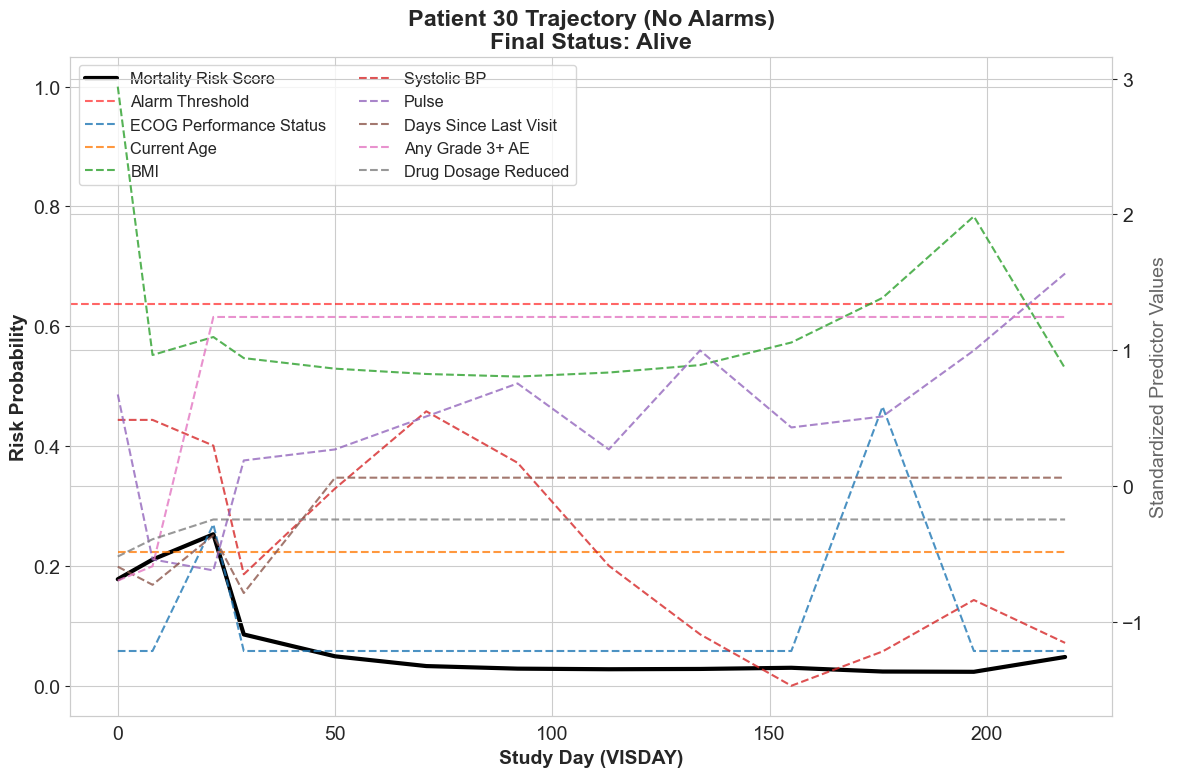

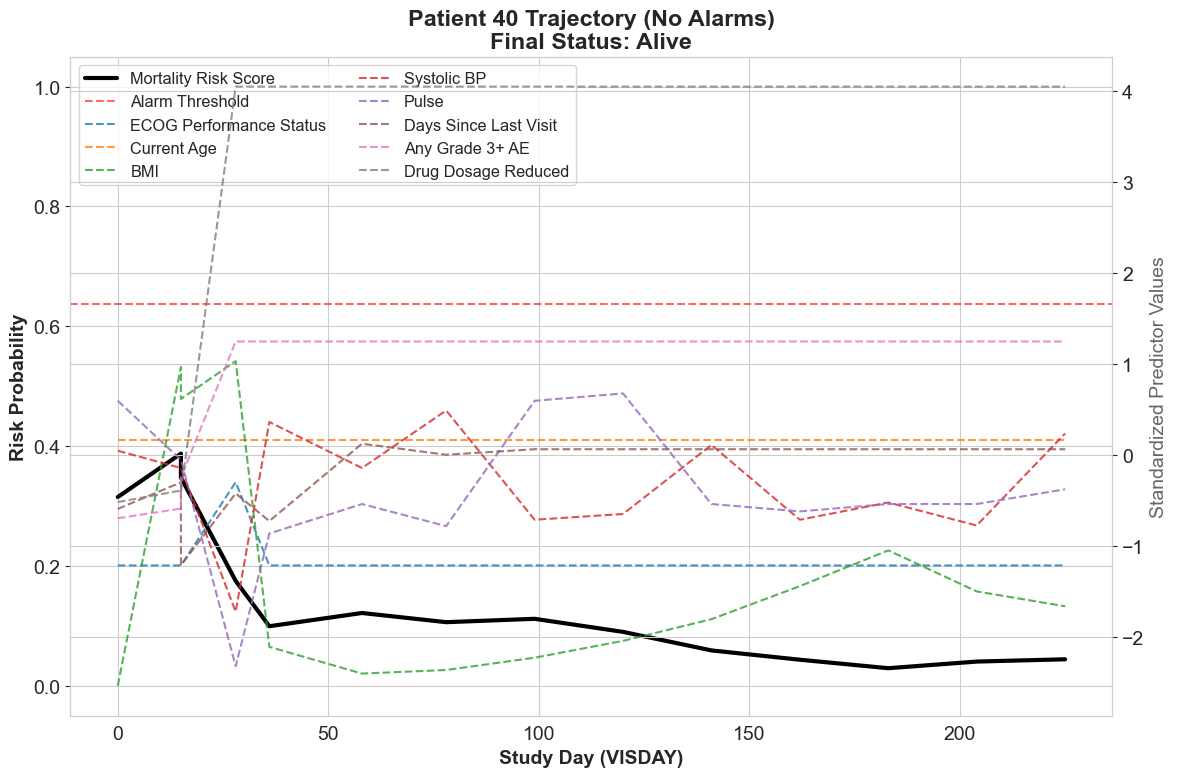

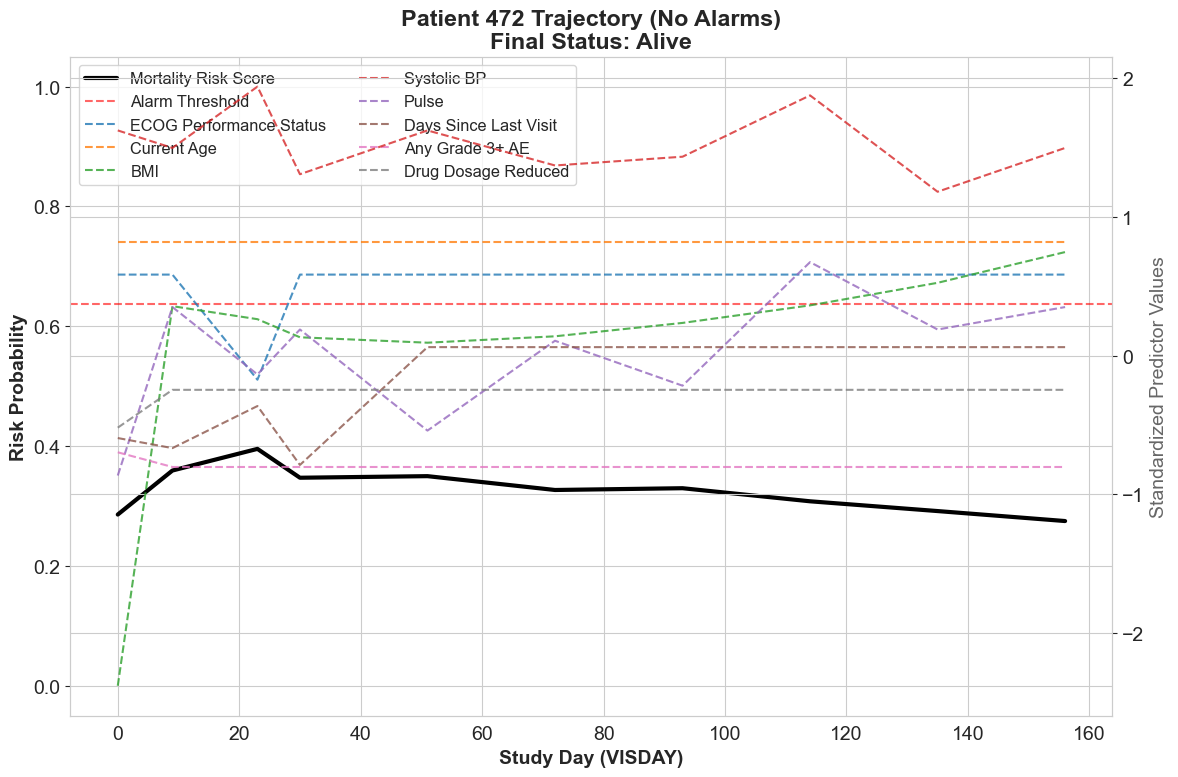

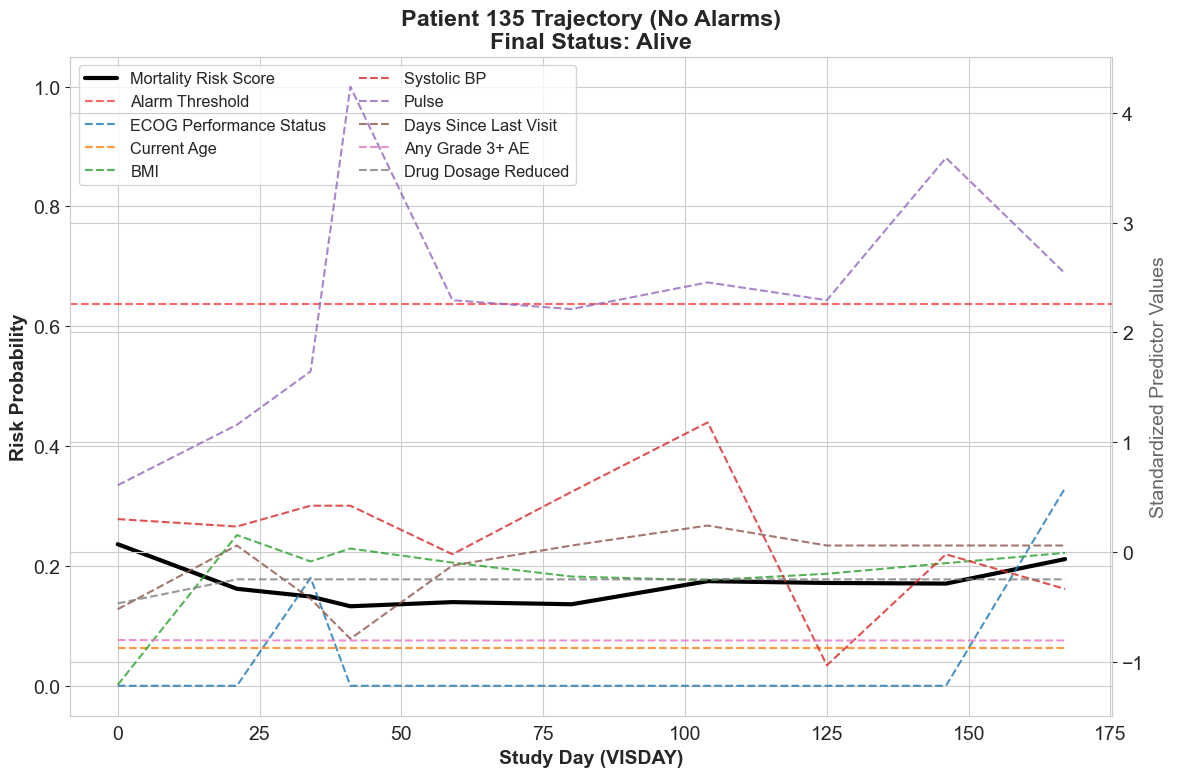

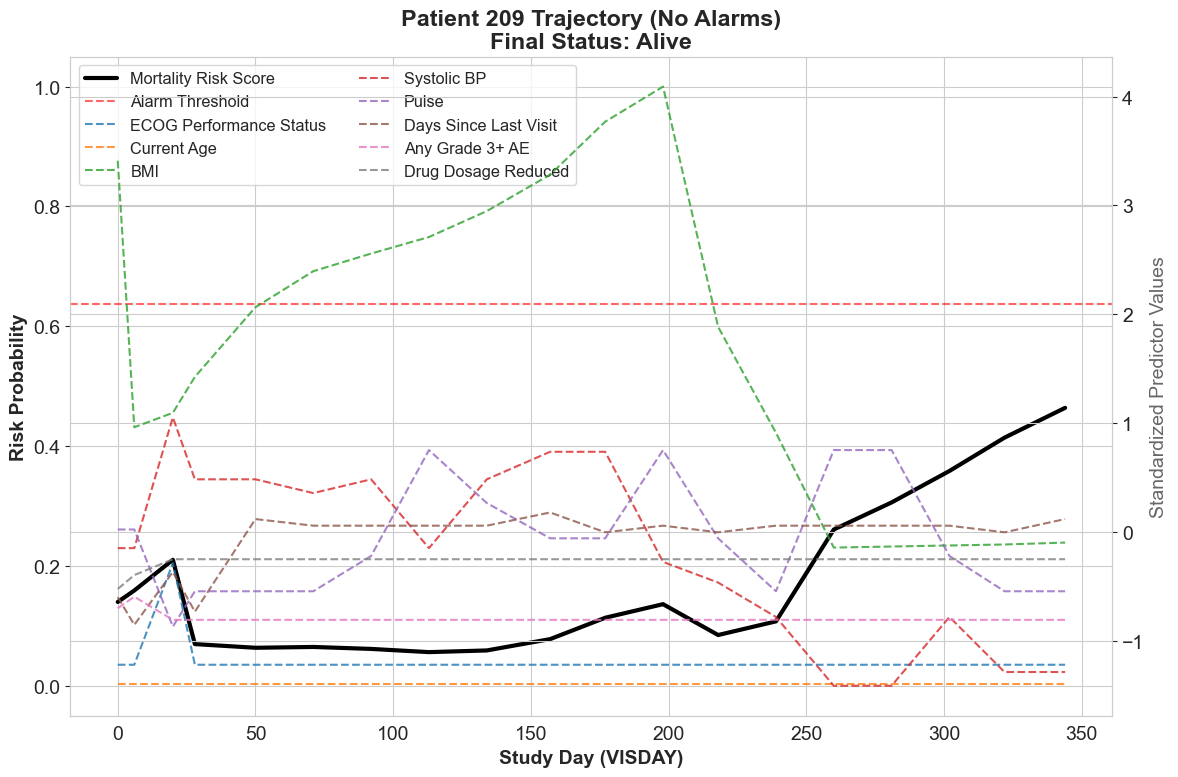

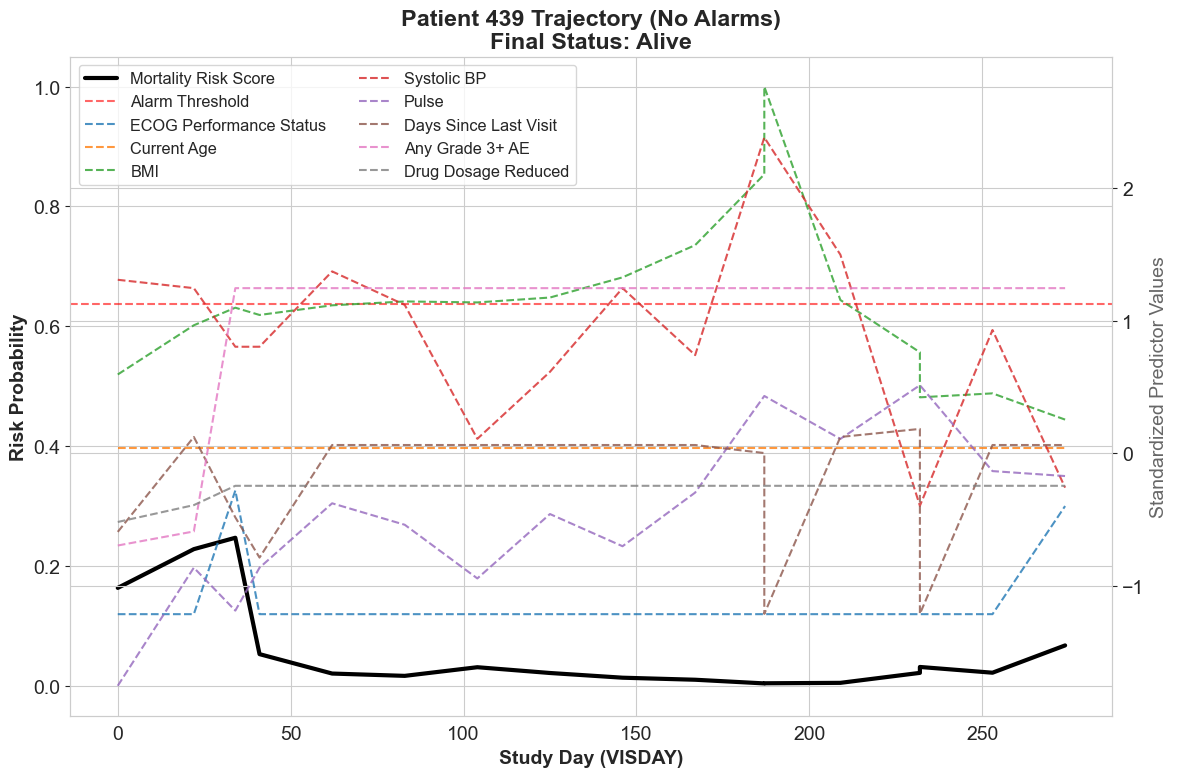

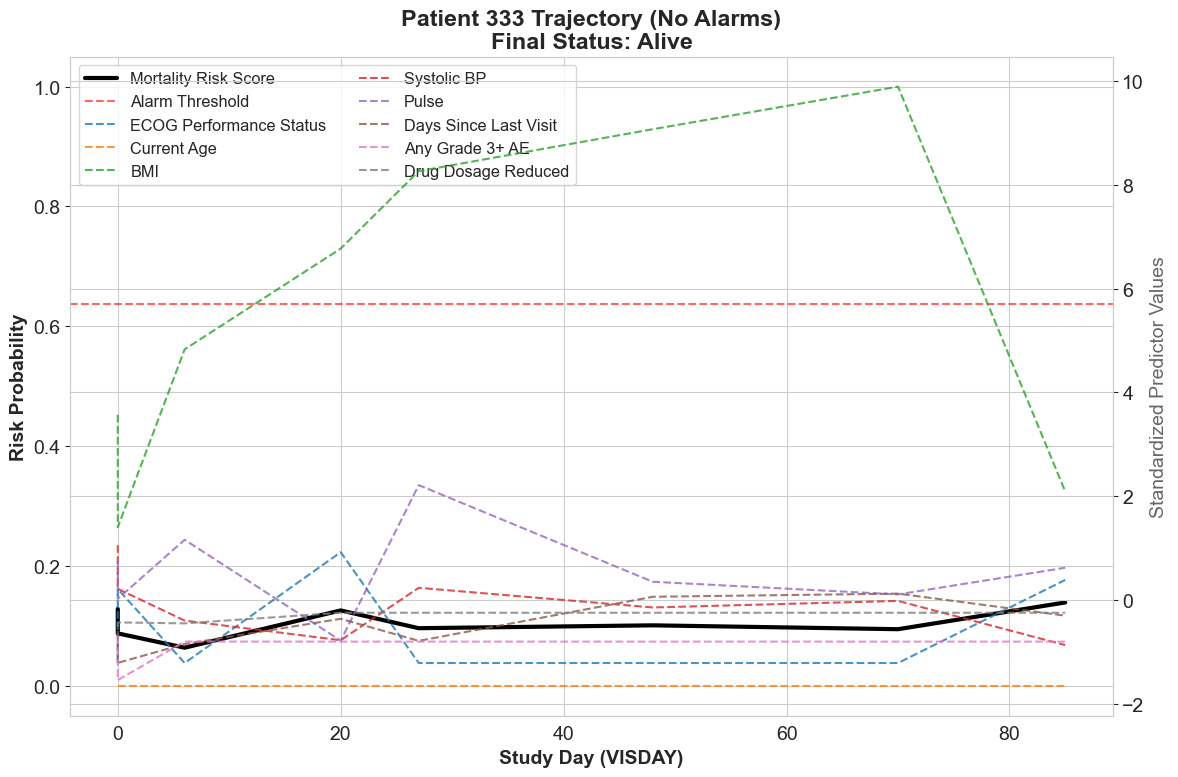

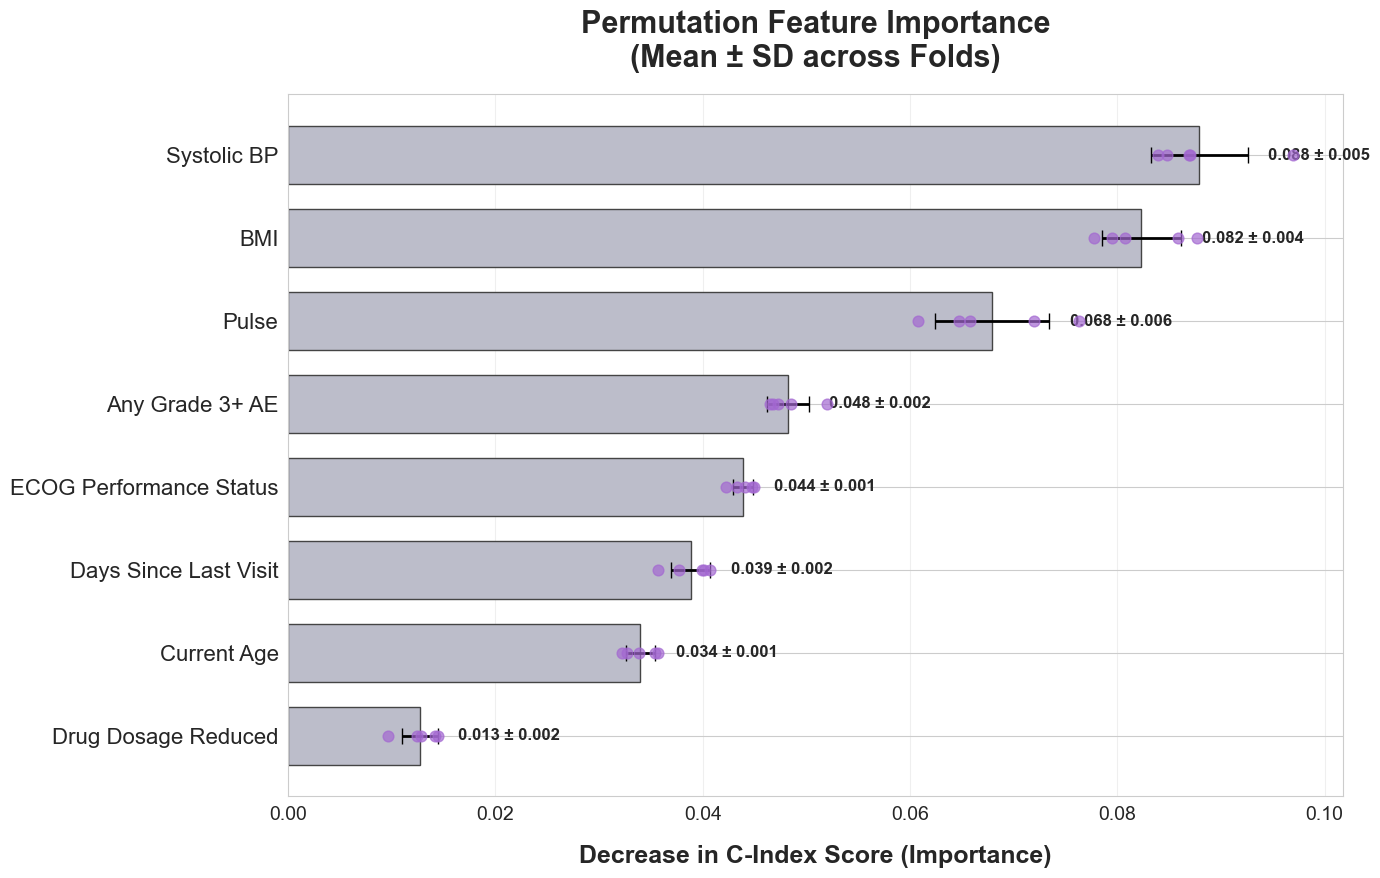

Calculating SHAP values for directionality and dependence analysis...


  0%|          | 0/250 [00:00<?, ?it/s]

/Users/javimencia/Desktop/HIVE Lab/Cancer Model/Main Experiment/PC002_De-id_Database 2/grumodel.py:368: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  center = (p + z**2/(2*n)) / denom


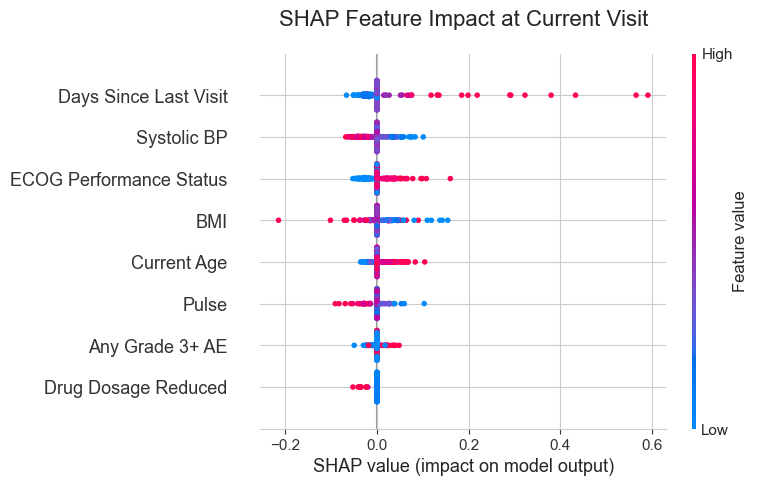

Generating SHAP Scatter Plots for variables...


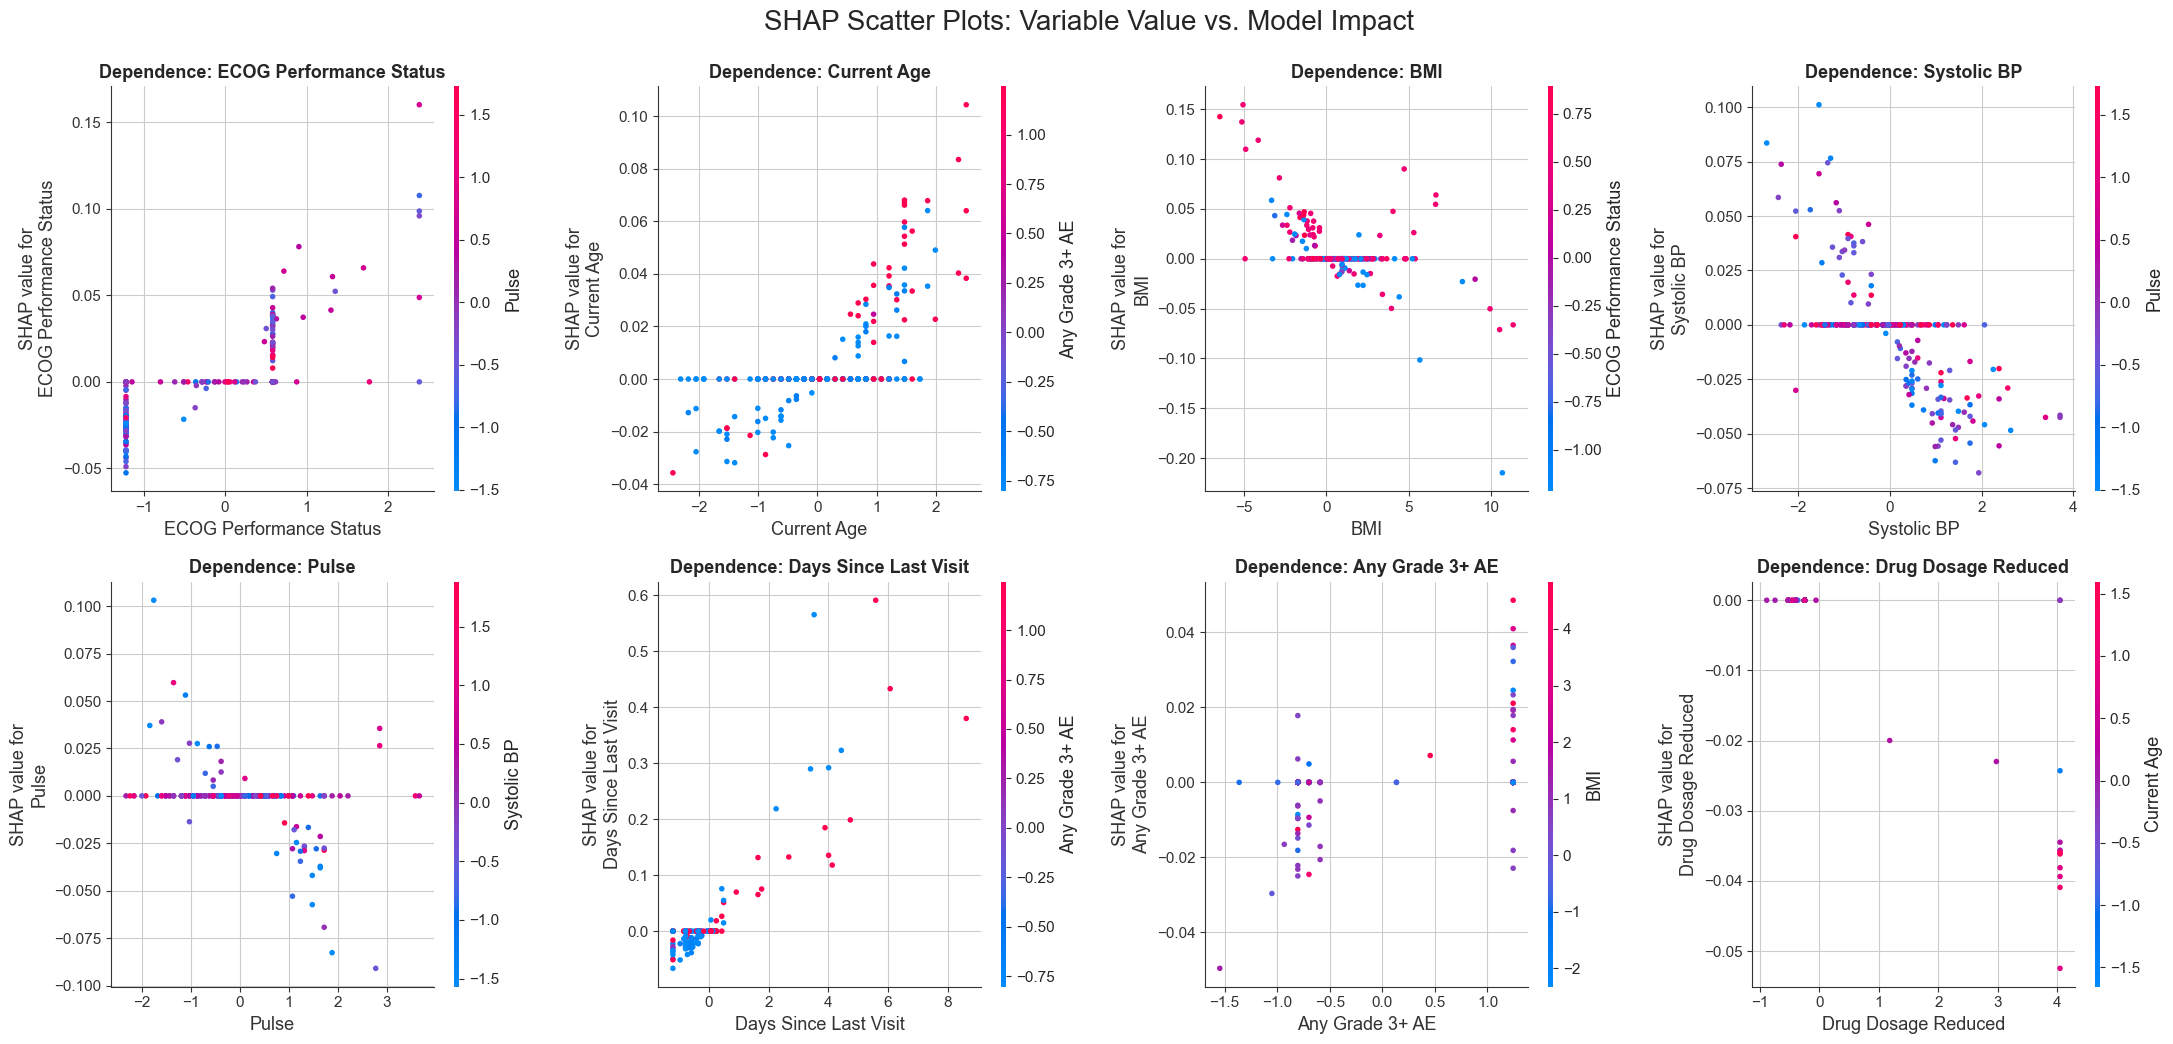

Generating Marginal Risk Sensitivity Curves...


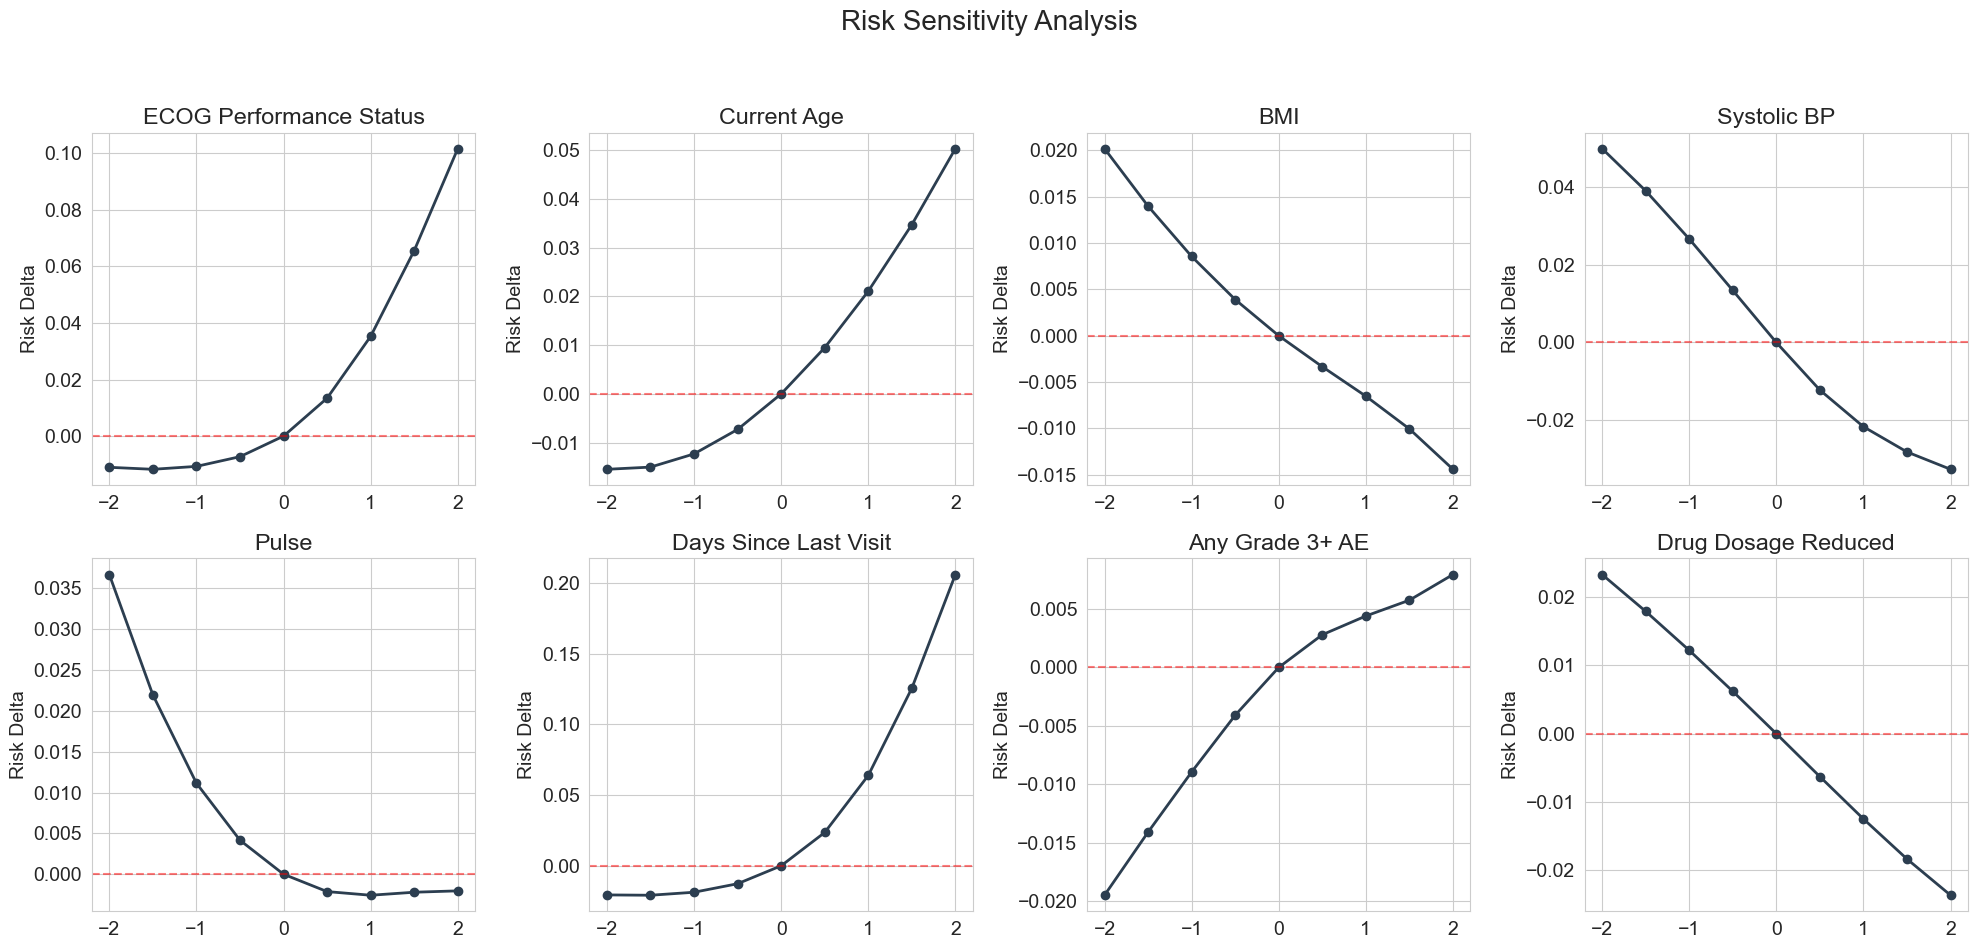

In [23]:
%load_ext autoreload
%autoreload 2

import grumodel

import pandas as pd

# 1. Load data
pcdata = pd.read_csv("/Users/javimencia/Desktop/HIVE Lab/Cancer Model/Main Experiment/PC002_De-id_Database 2/pcdata.csv")

# 2. Define features
internal_columns = [
    'ECOG Performance Status', 'Current Age', 'BMI', 'Systolic BP', 'Pulse',
    'Days Since Last Visit', 'Any Grade 3+ AE', 'Drug Dosage Reduced'
]

features = [
    'ECOGGRN', 'AGE', 'BMI', 'SYSBP', 'PULSE',
    'days_since_last_visit', 'any_grade3_plus', 'drug_reduced'
]

pipeline = grumodel.SequentialSurvivalGRU(
    internal_columns,
    features,
    horizon = 180,
    sequence_length = 12
)

# 4. Run the analysis
pipeline.run_analysis(pcdata)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/var/folders/x9/3zl22m596tl6d44cbs62z6h00000gn/T/ipykernel_66690/1186913396.py:9: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  pcvaldata = pd.read_csv("/Users/javimencia/Desktop/HIVE Lab/Cancer Model/Main Experiment/PC002_De-id_Database 2/pcvaldata.csv")


Training Temporal GRU Autoencoder for Imputation...
874/874 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
Training Survival GRU...
------------------------------
C-Index: 0.8035
Sensitivity (Recall): 0.8603 [0.854, 0.866]
Specificity         : 0.6922 [0.685, 0.699]
PPV (Precision)     : 0.7078 [0.701, 0.715]
NPV                 : 0.8511 [0.845, 0.857]
Balanced Accuracy   : 0.7762 [0.771, 0.781]

Metric                              | Value      | Category
-----------------------------------------------------------------
Alerts per 100 Patient-Visits       | 18.3       | Clinical Burden
Proportion of Visits in Alert       | 18.31%     | Alarm Density
Median TIW (True Positives)         | 181.0 days | Lead Time
Median TIW (False Positives)        | 59.0 days  | Noise Duration


Slope: 1.0387 | Intercept: -0.0003 | R-sq: 0.9899


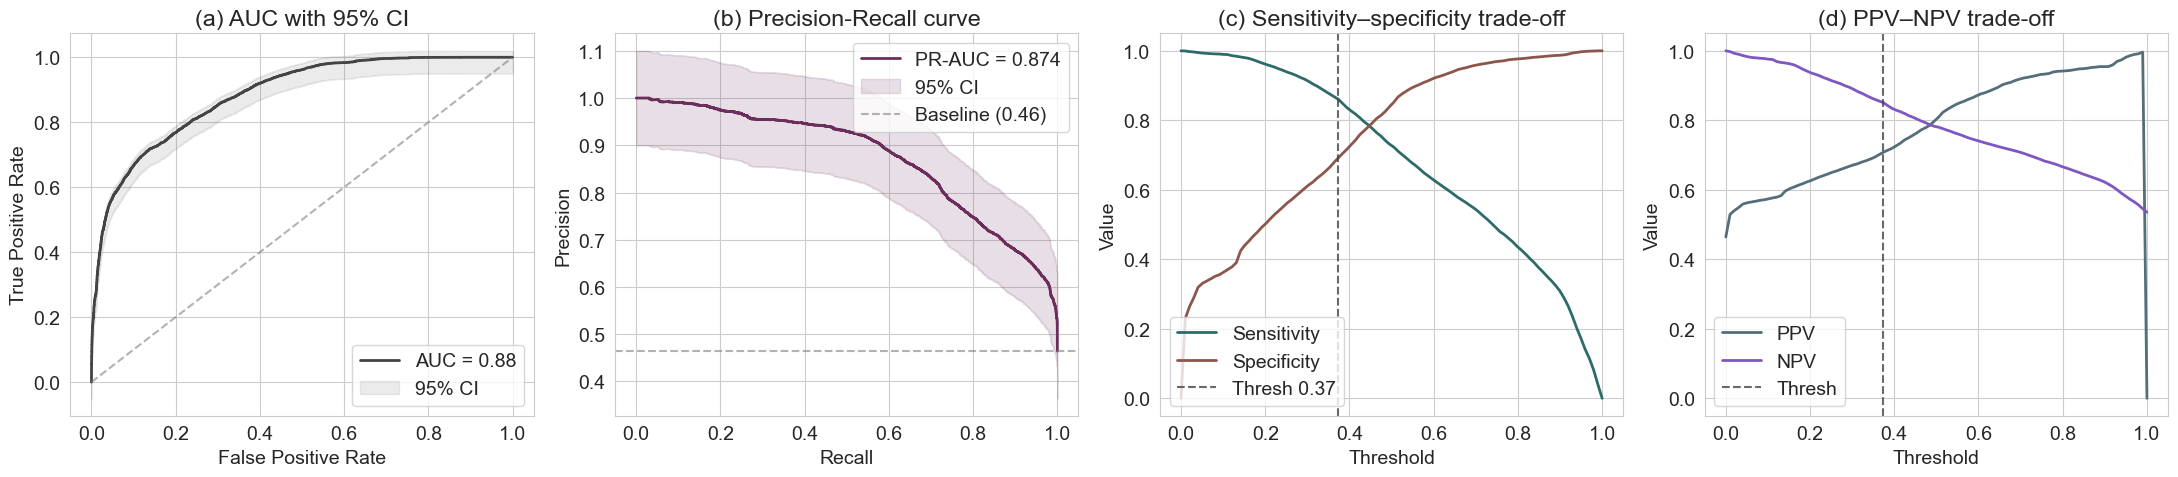

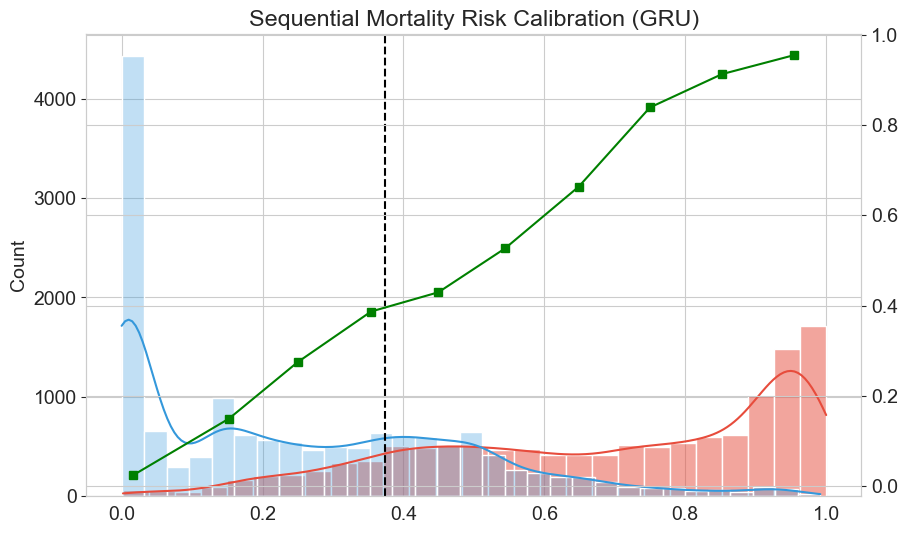

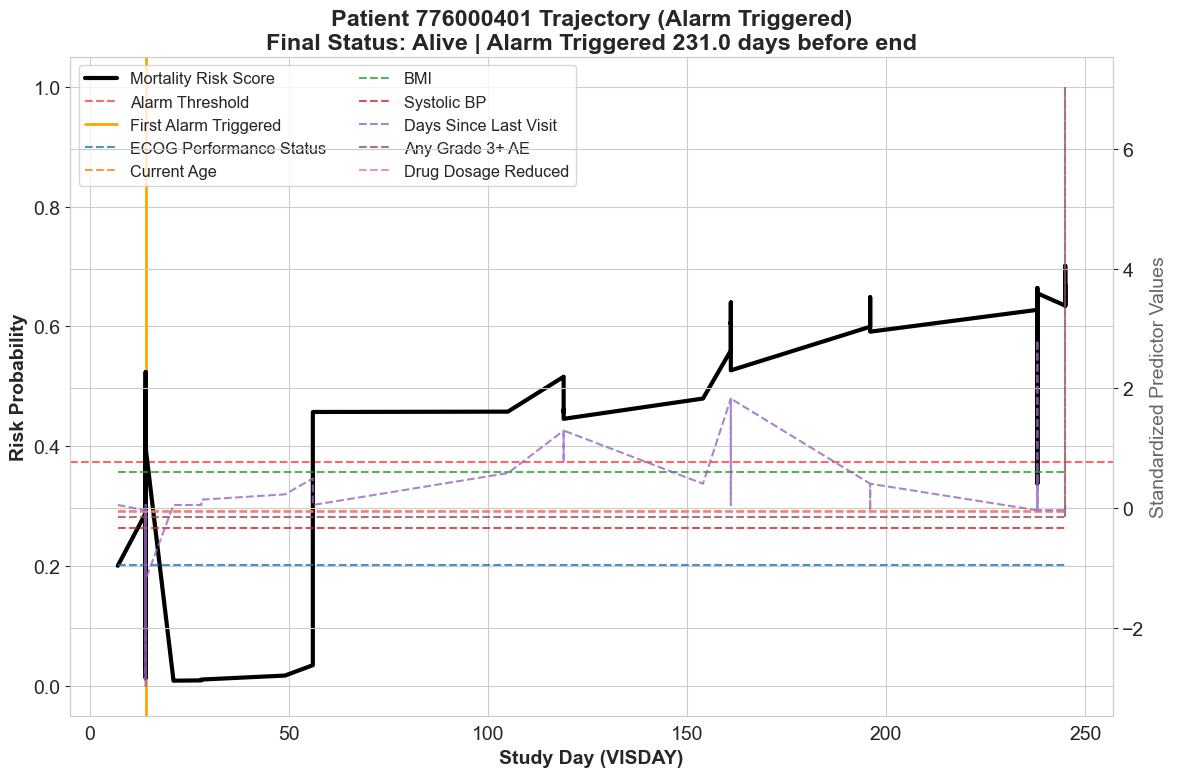

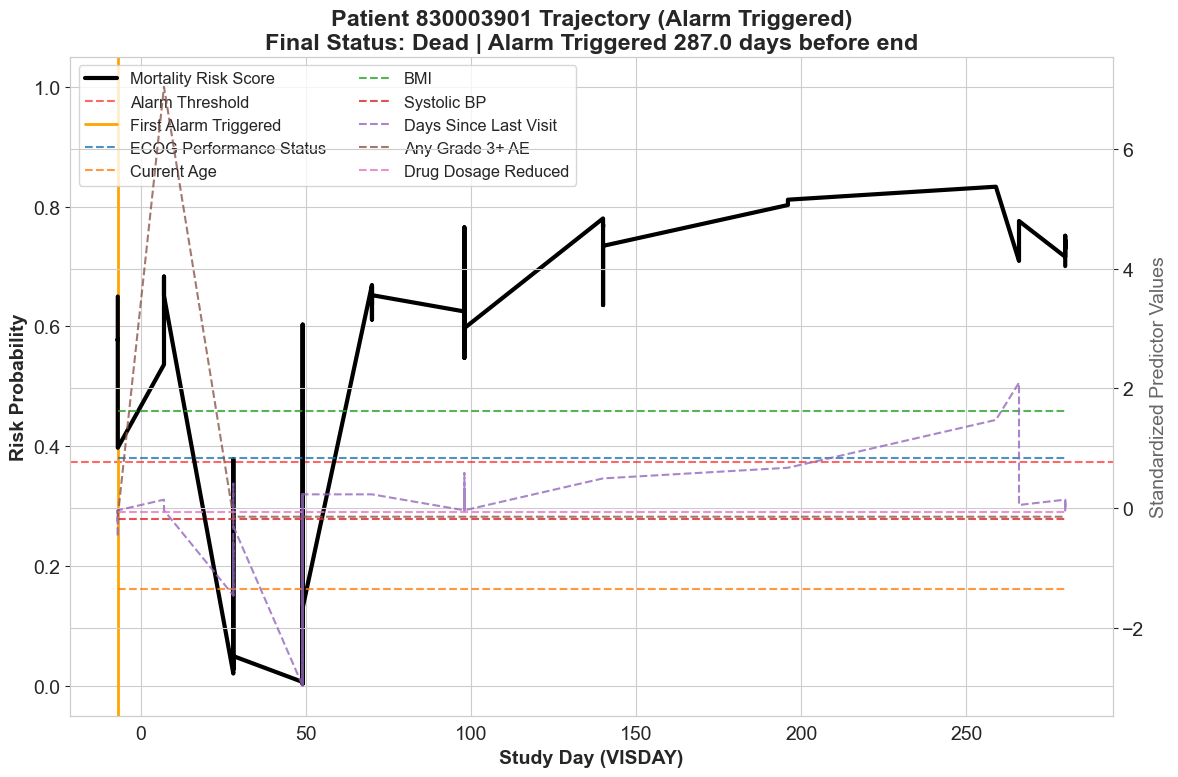

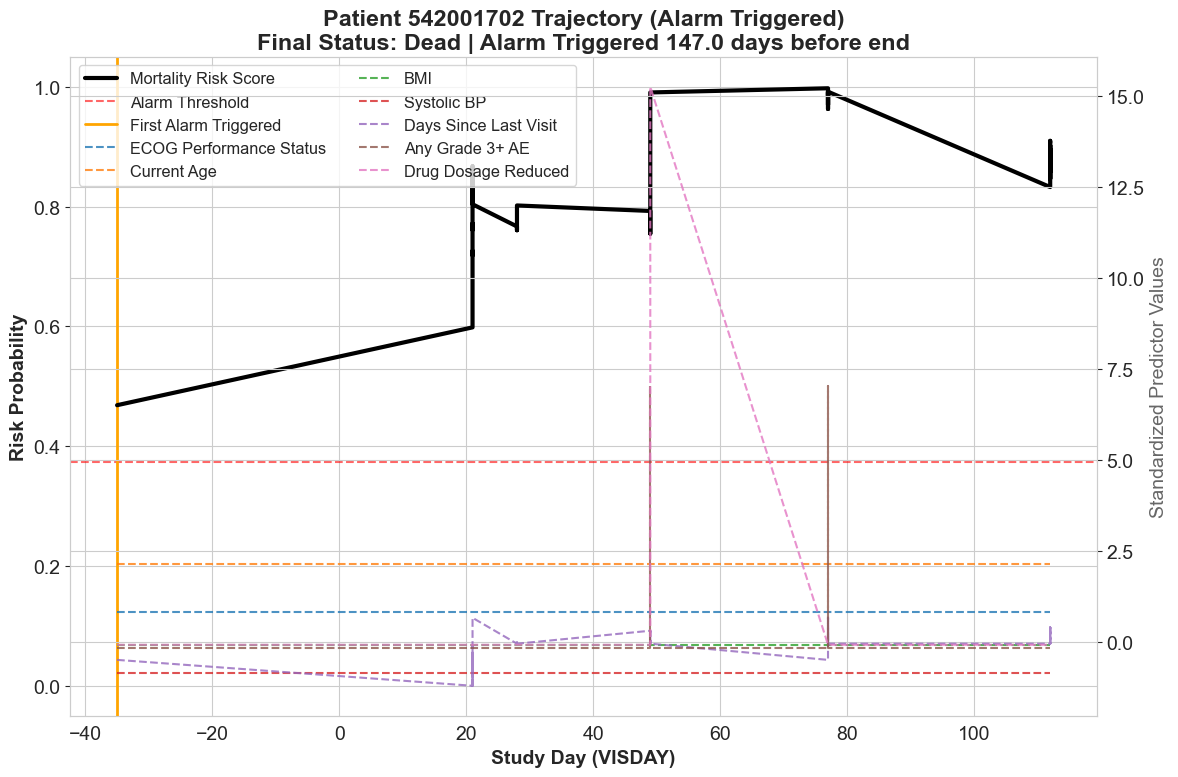

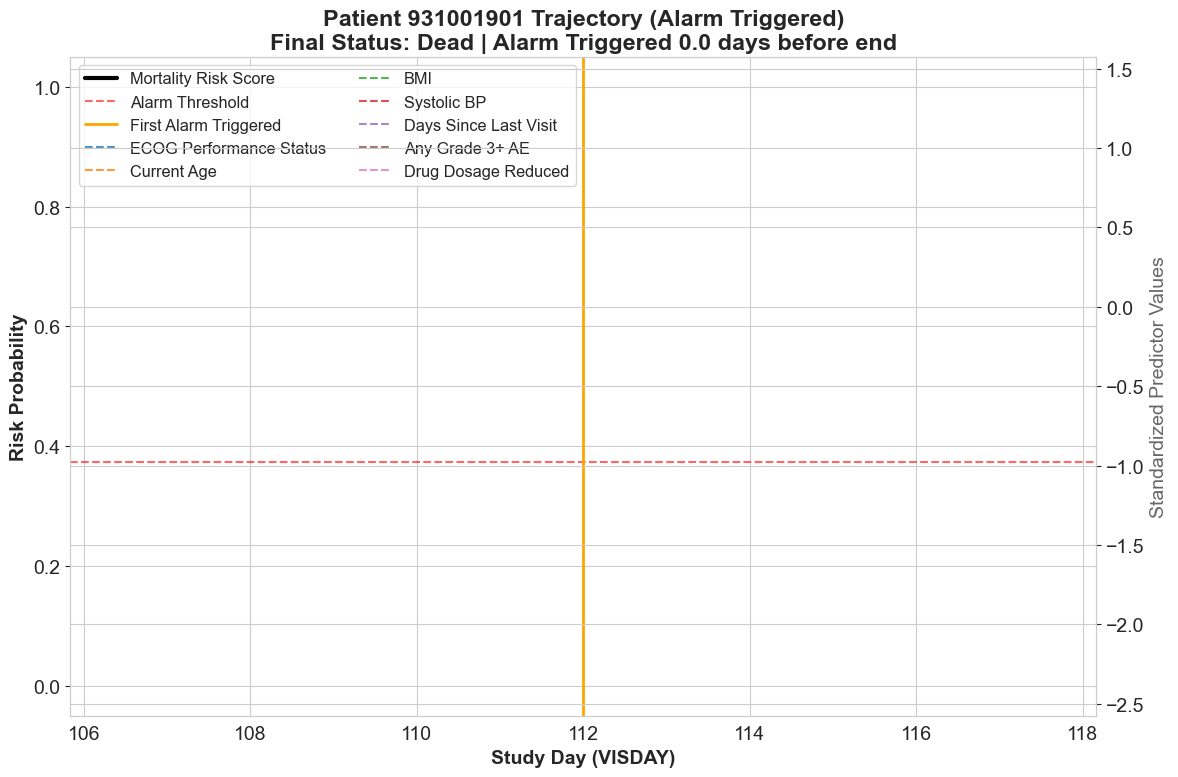

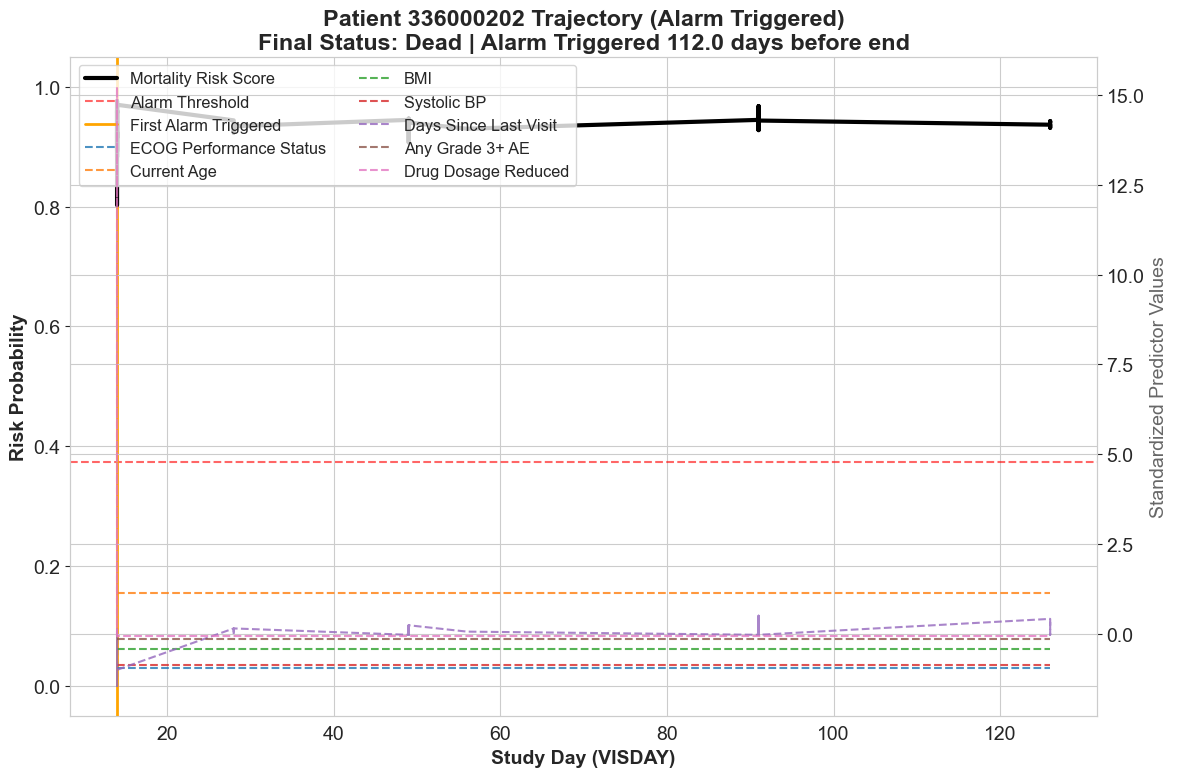

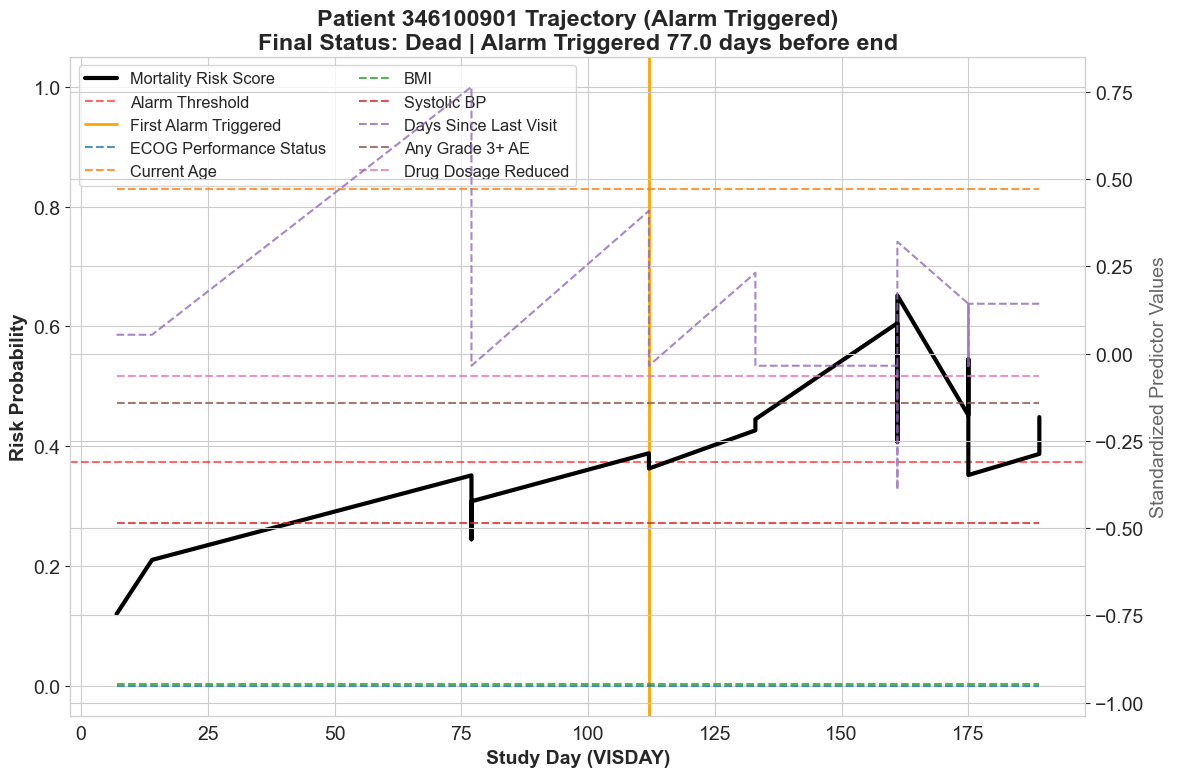

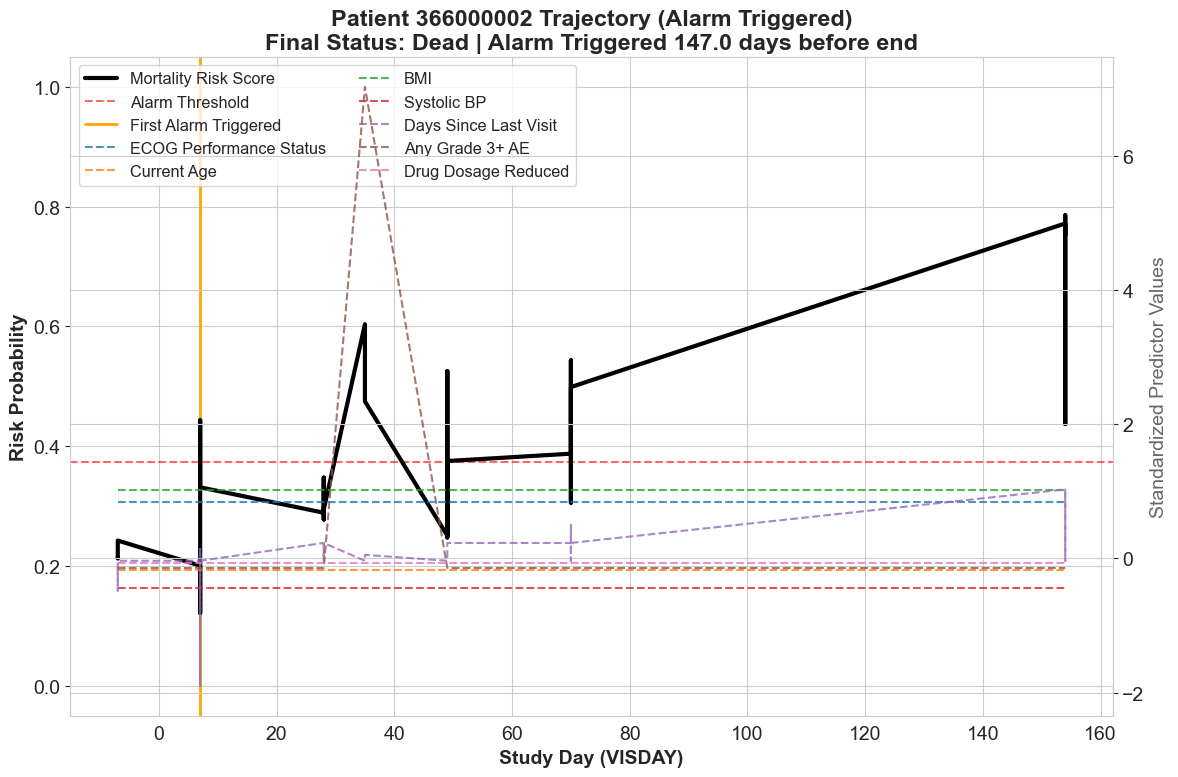

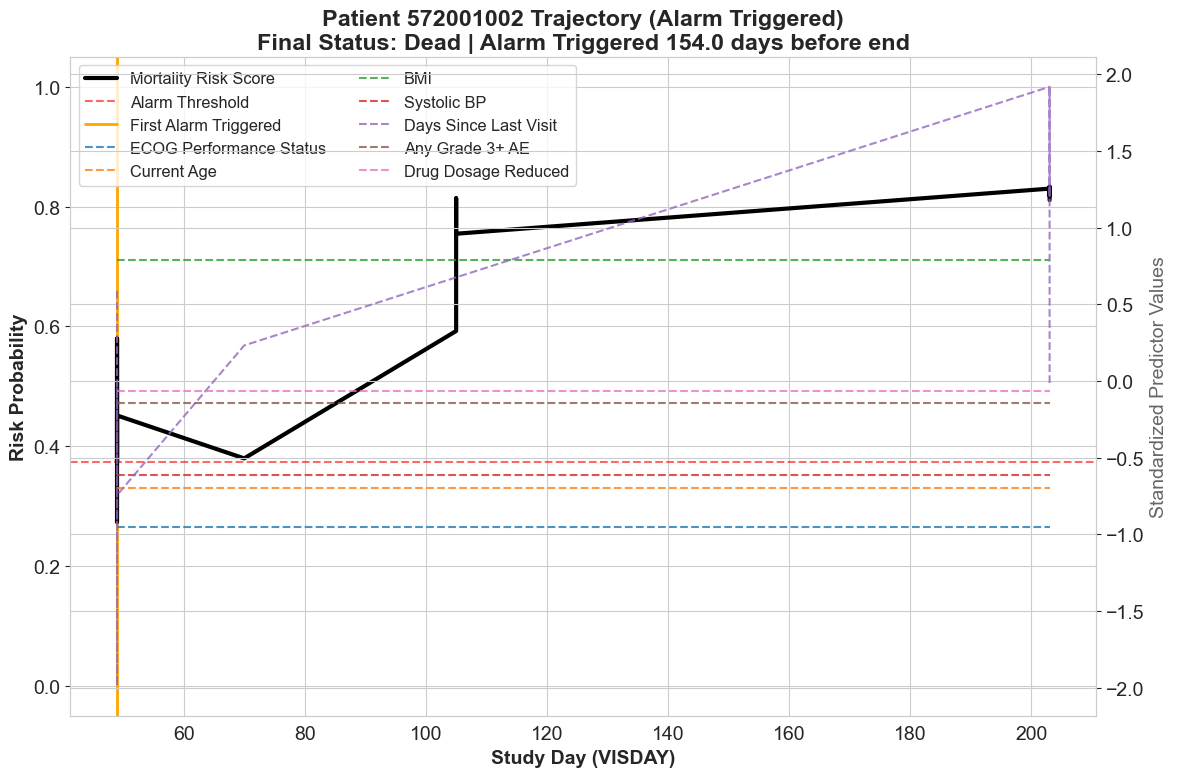

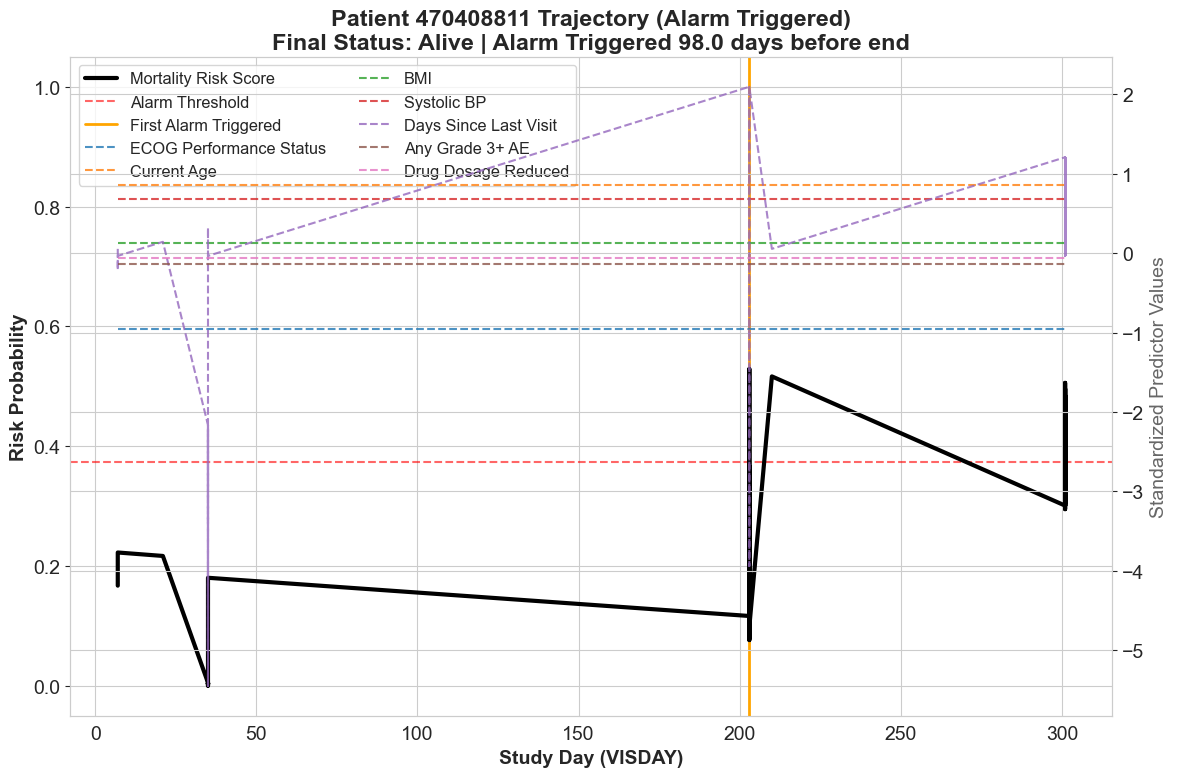

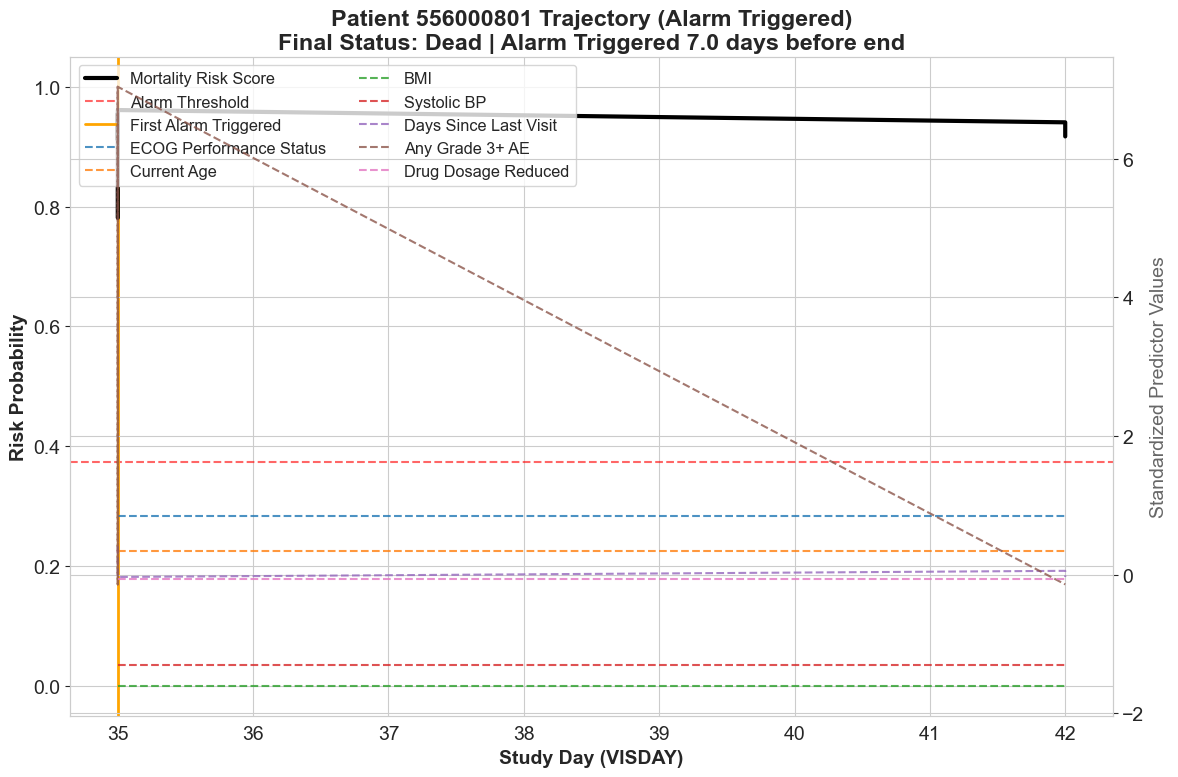

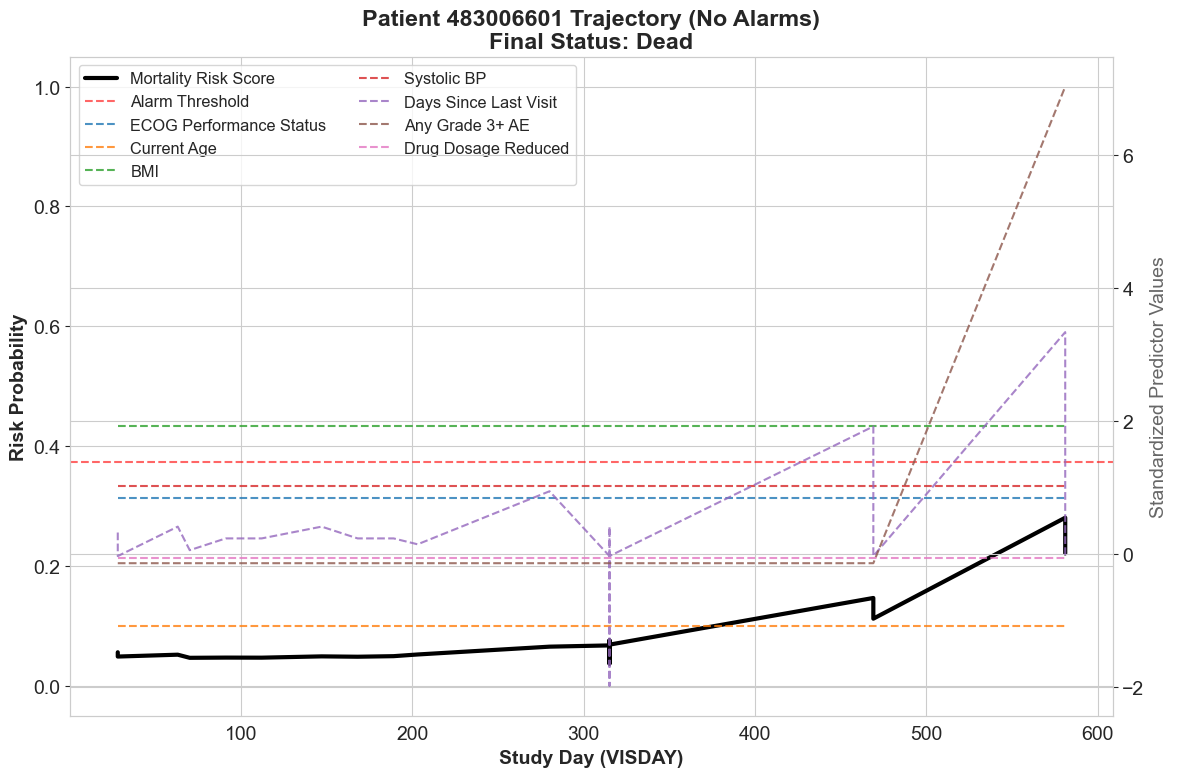

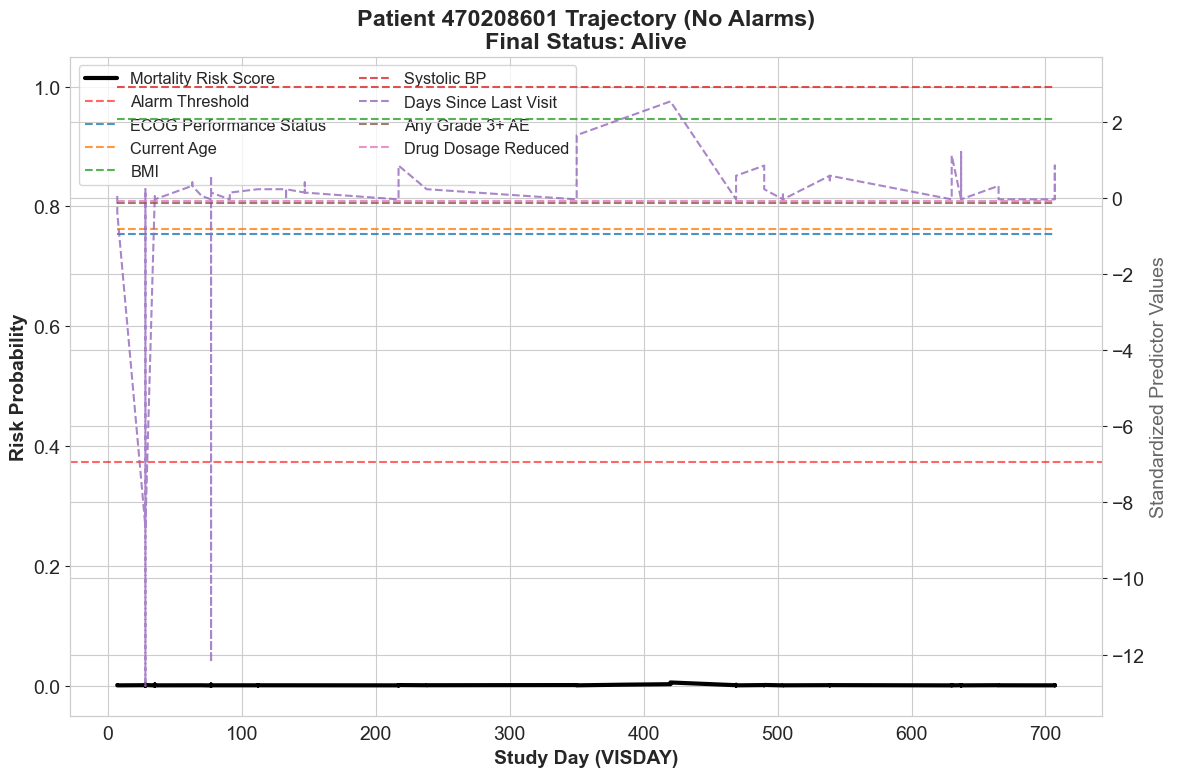

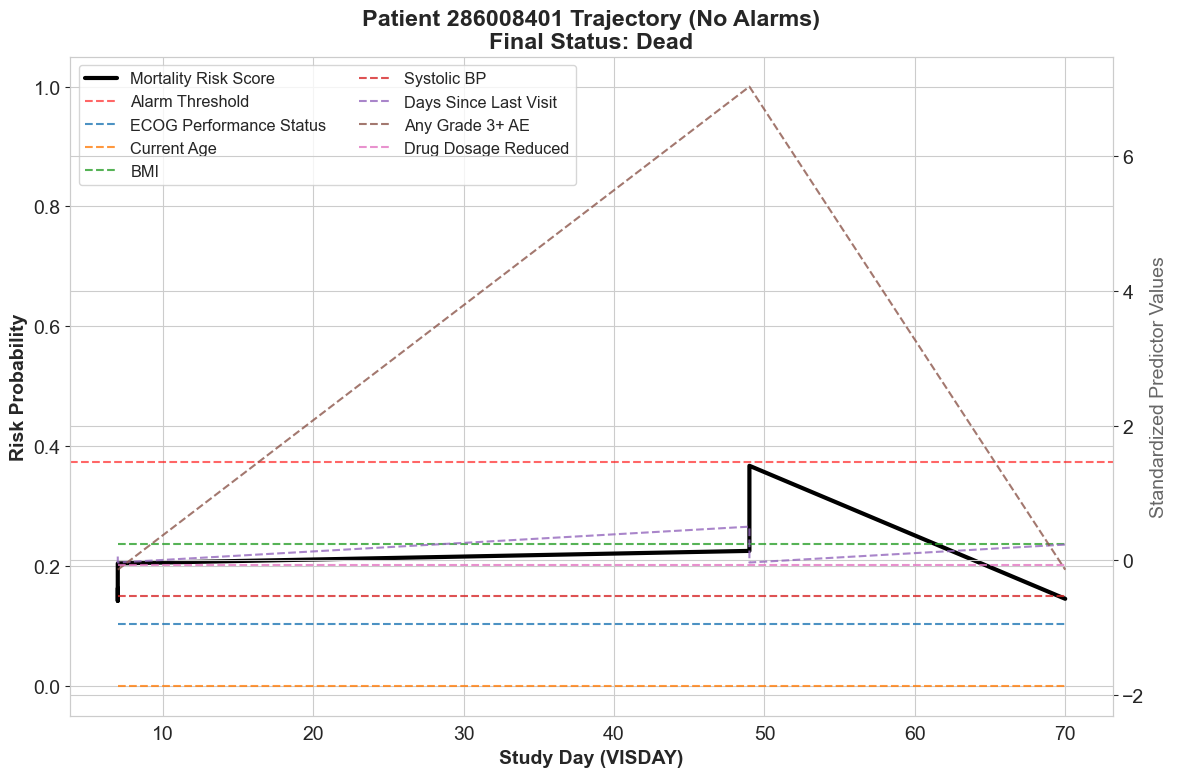

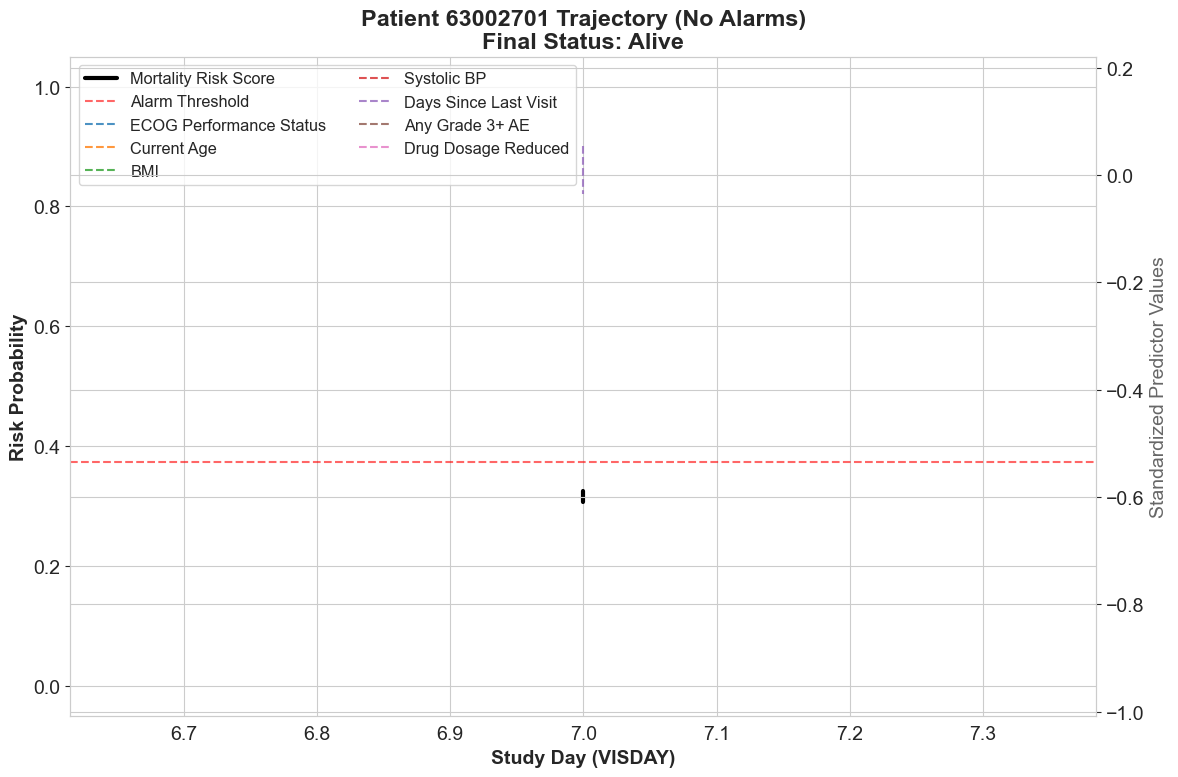

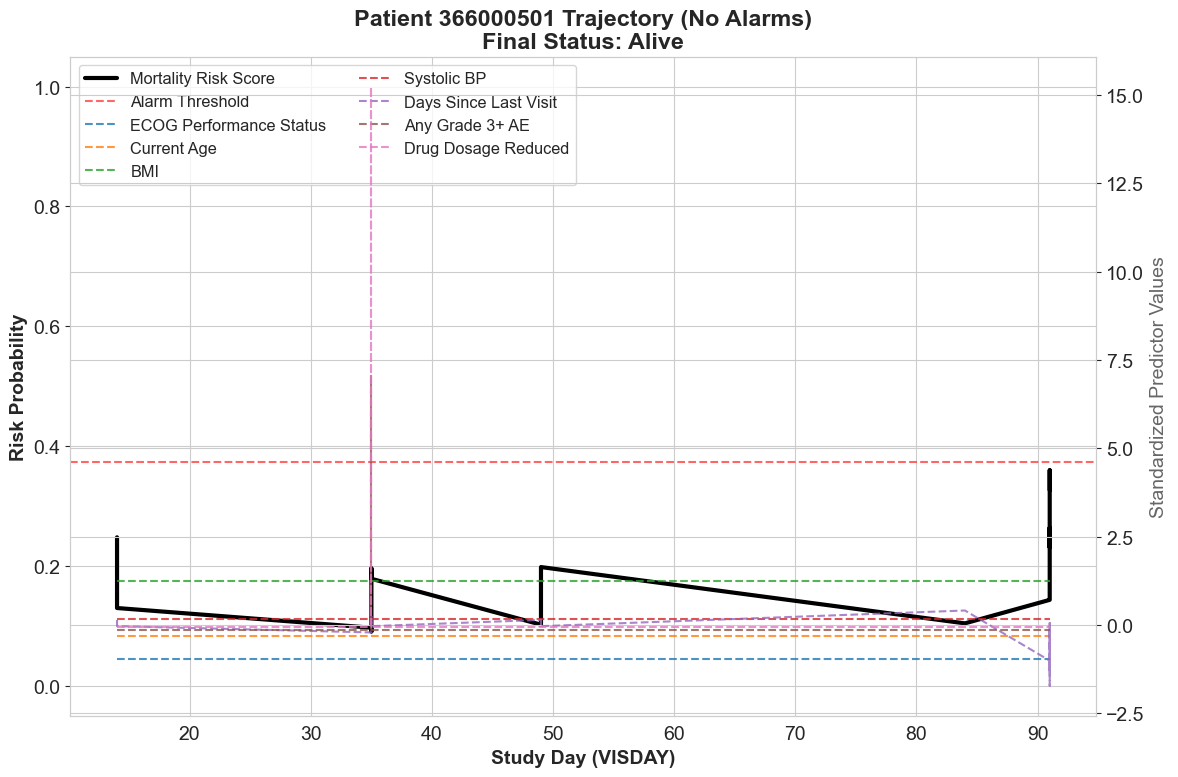

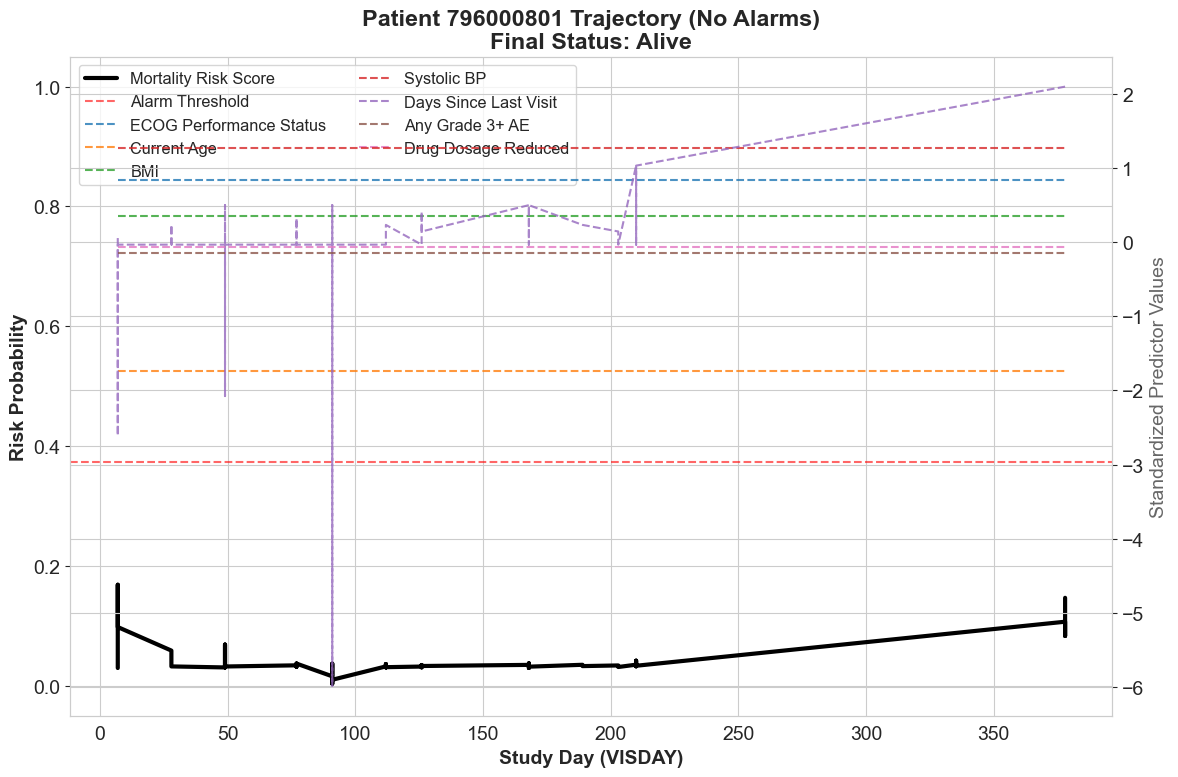

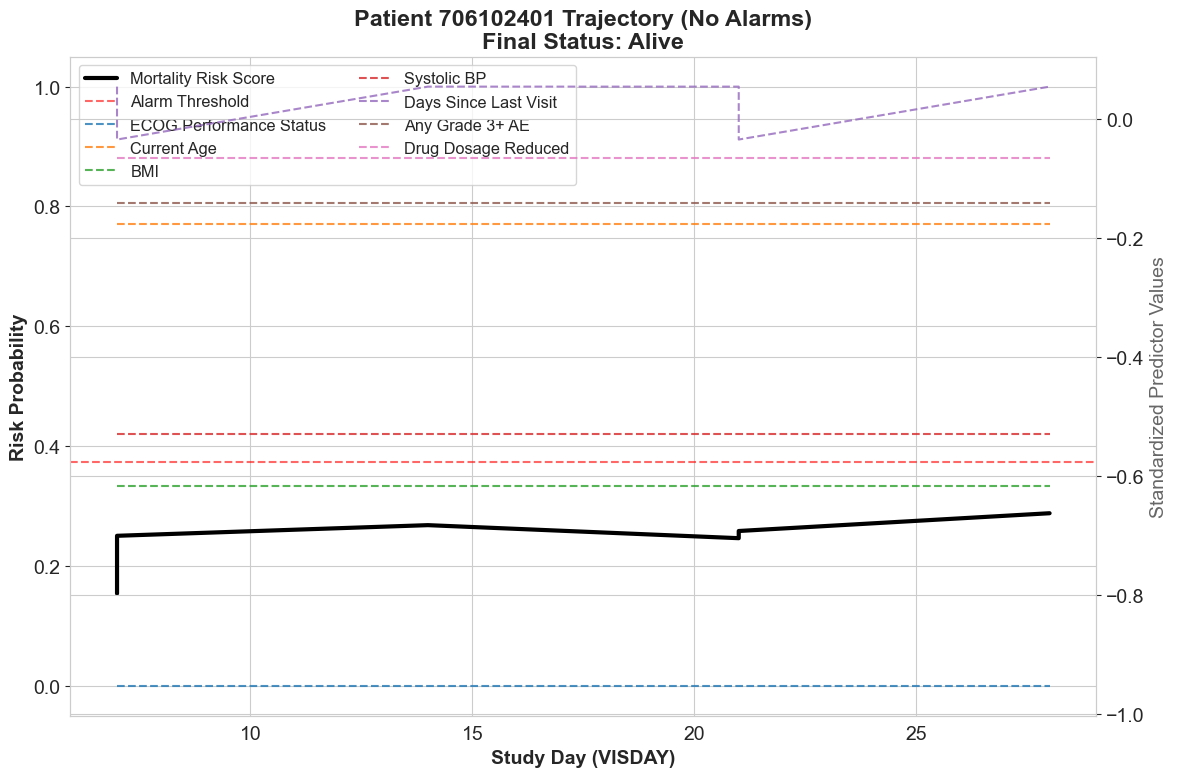

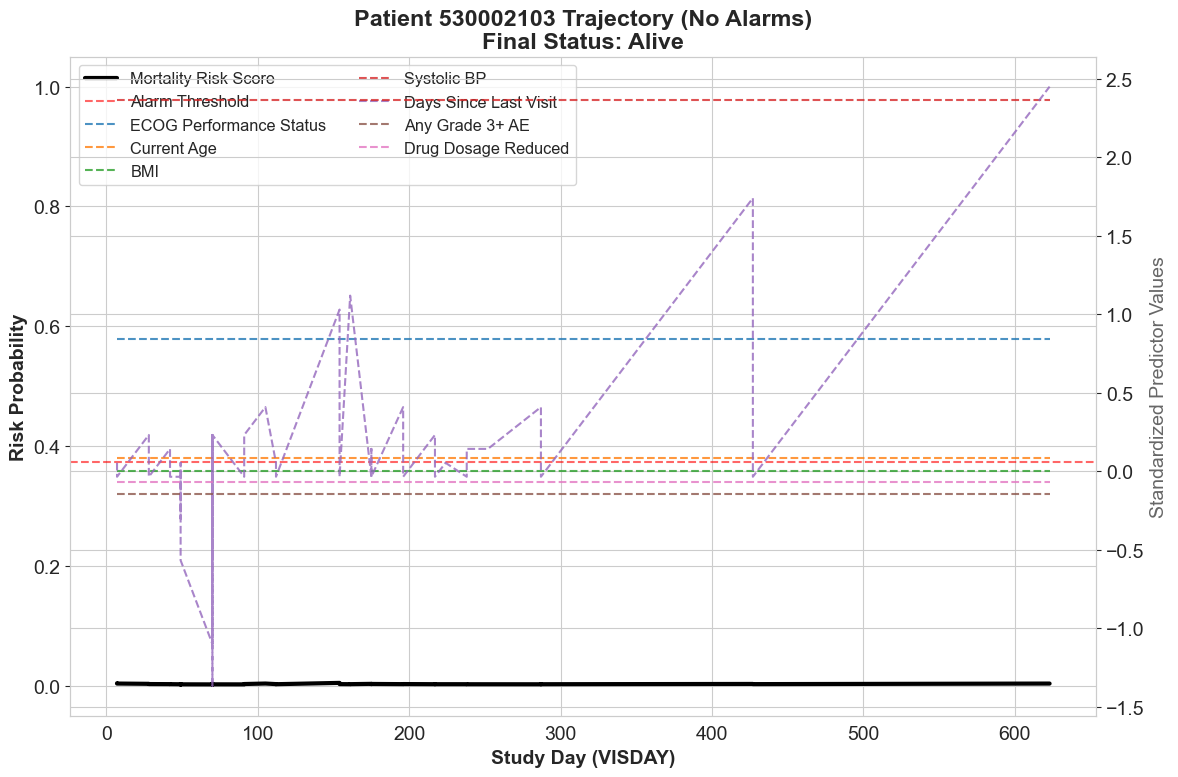

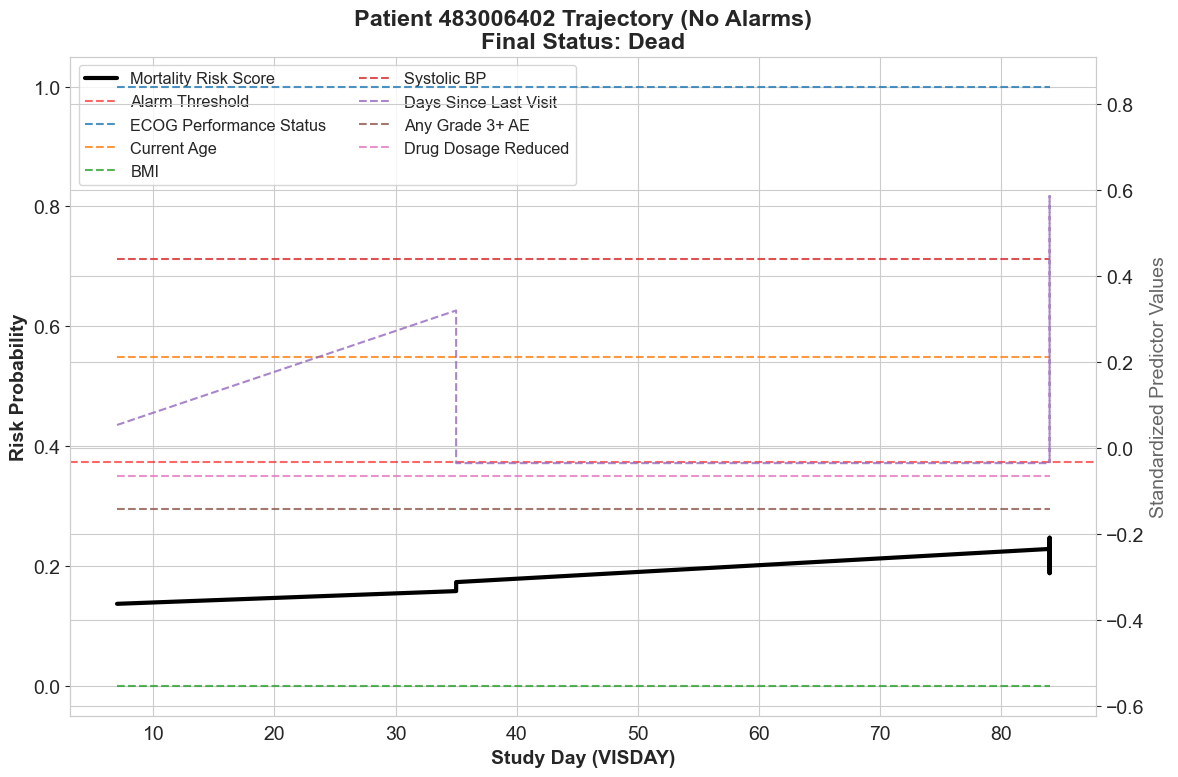

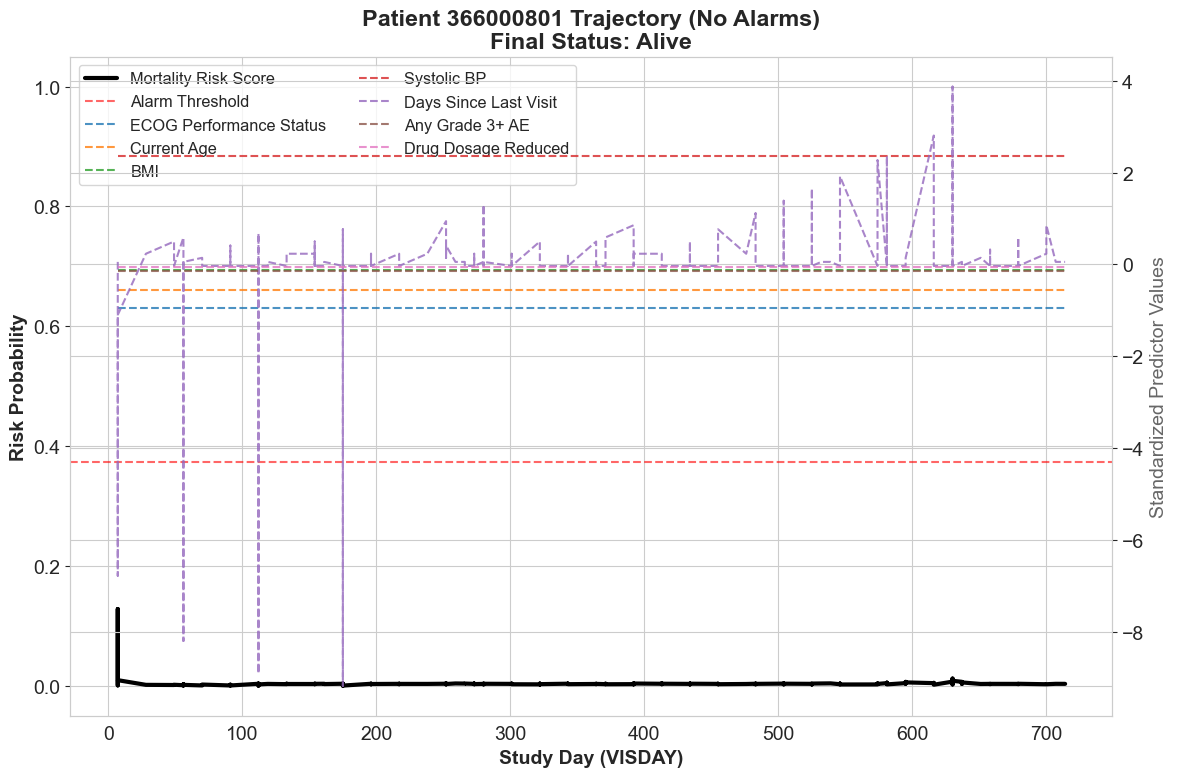

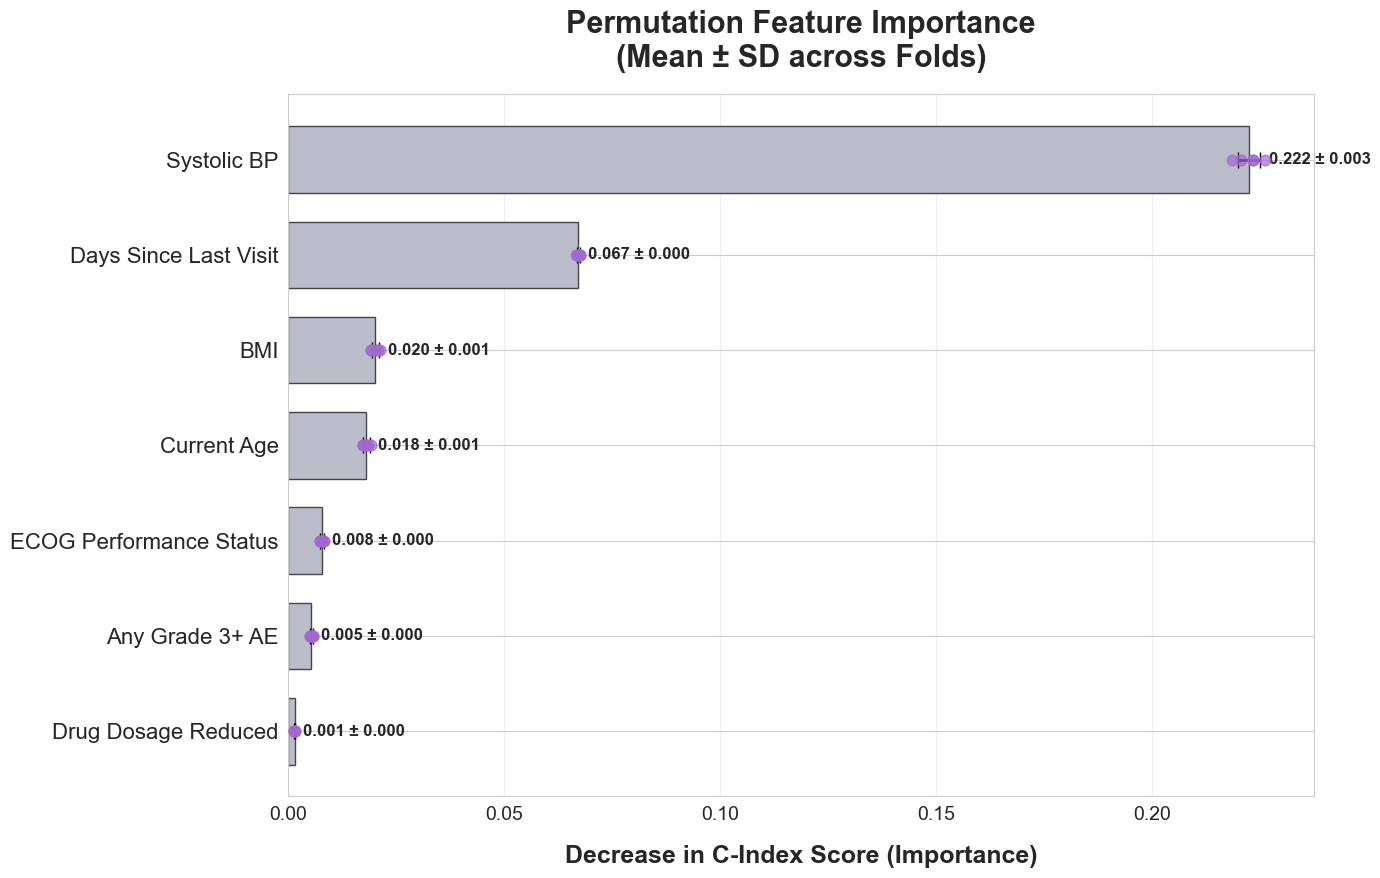

Calculating SHAP values for directionality and dependence analysis...


  0%|          | 0/250 [00:00<?, ?it/s]

/Users/javimencia/Desktop/HIVE Lab/Cancer Model/Main Experiment/PC002_De-id_Database 2/grumodel.py:368: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  center = (p + z**2/(2*n)) / denom


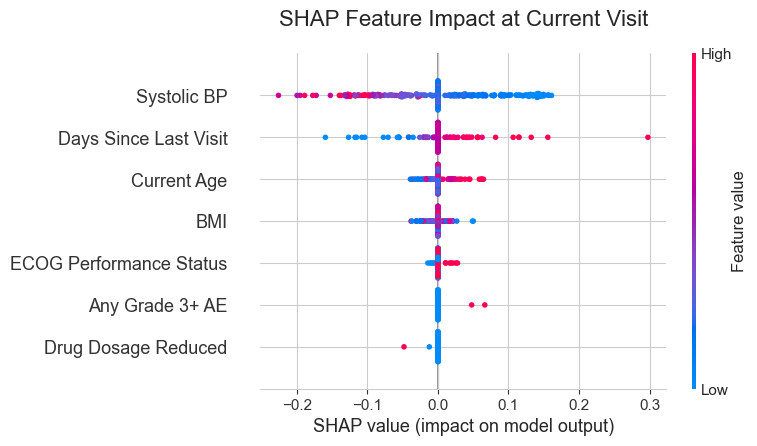

Generating SHAP Scatter Plots for variables...


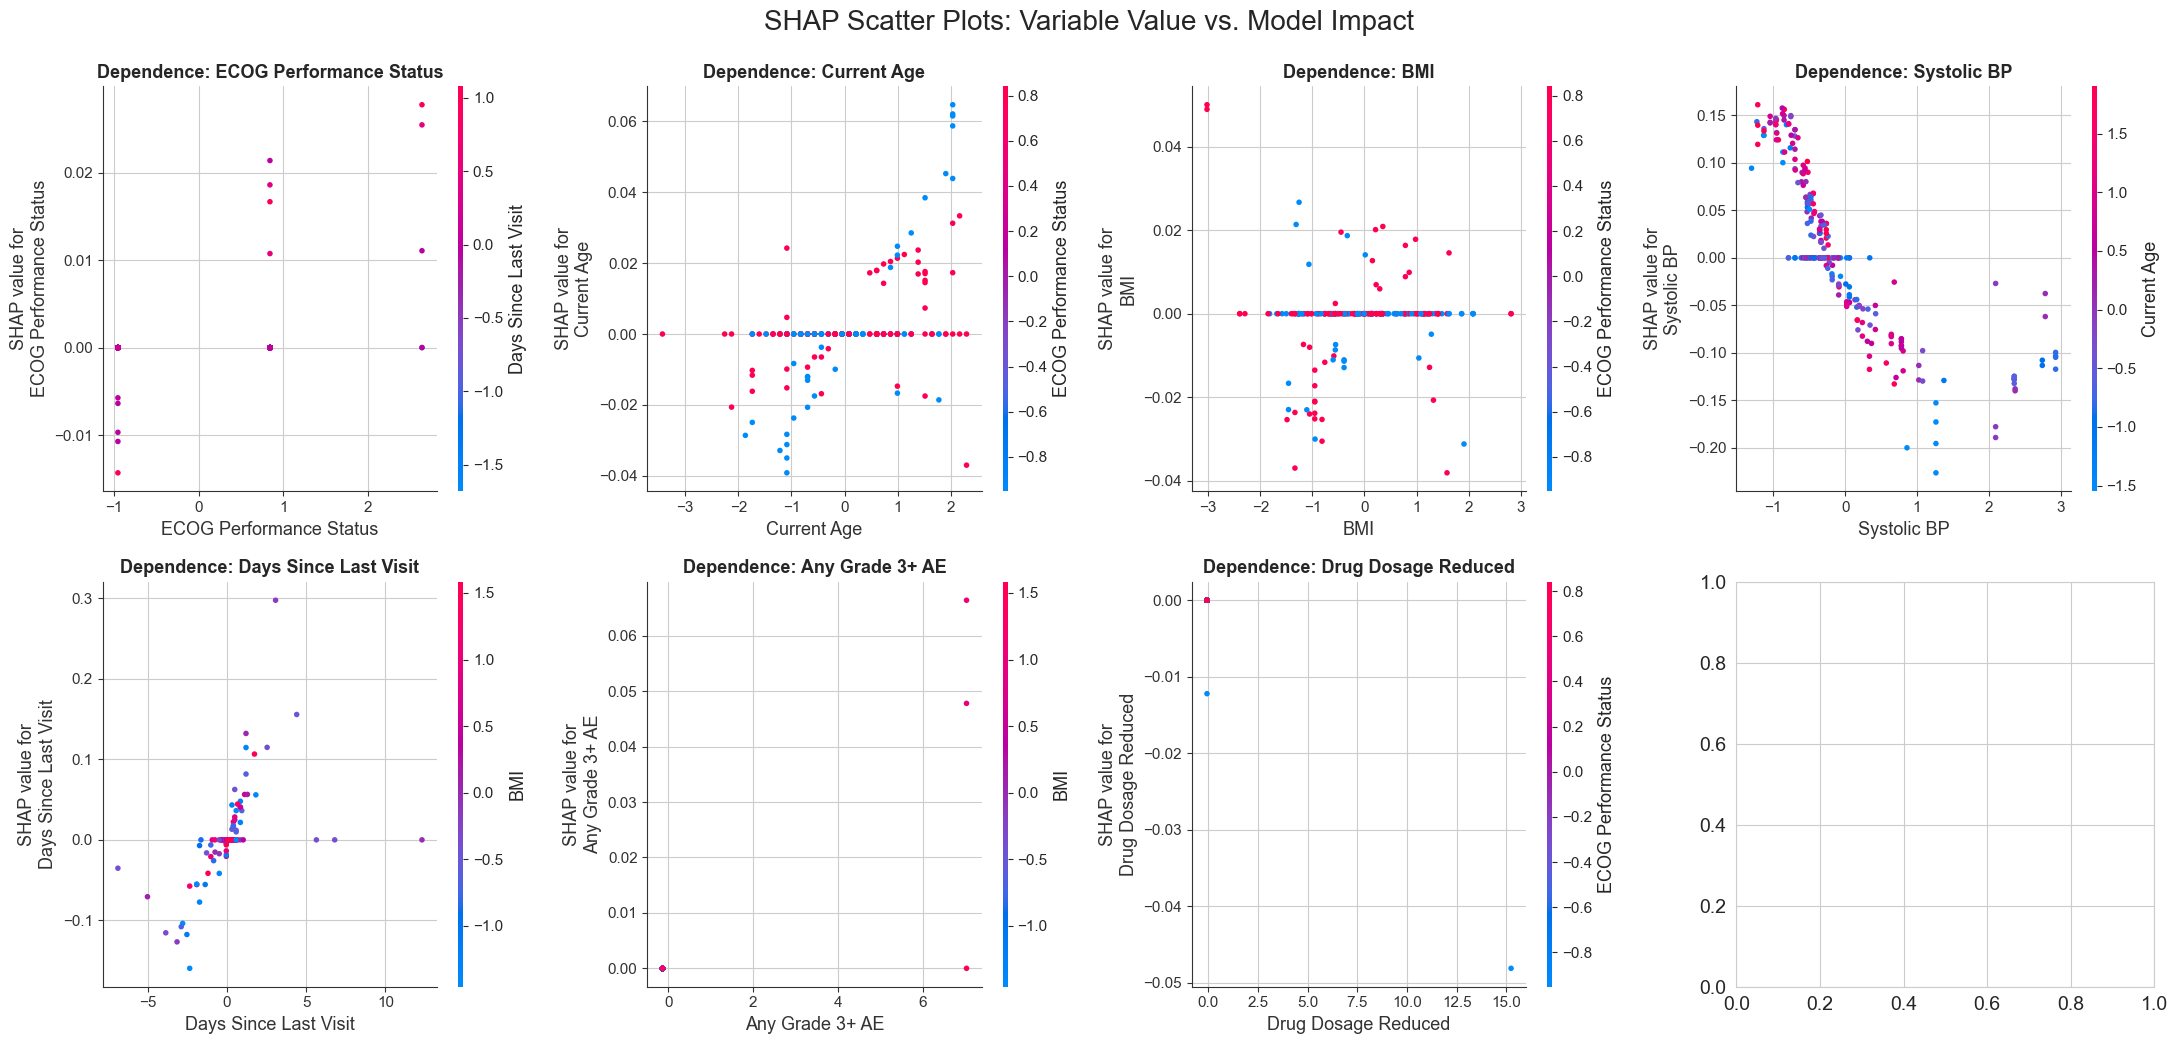

Generating Marginal Risk Sensitivity Curves...


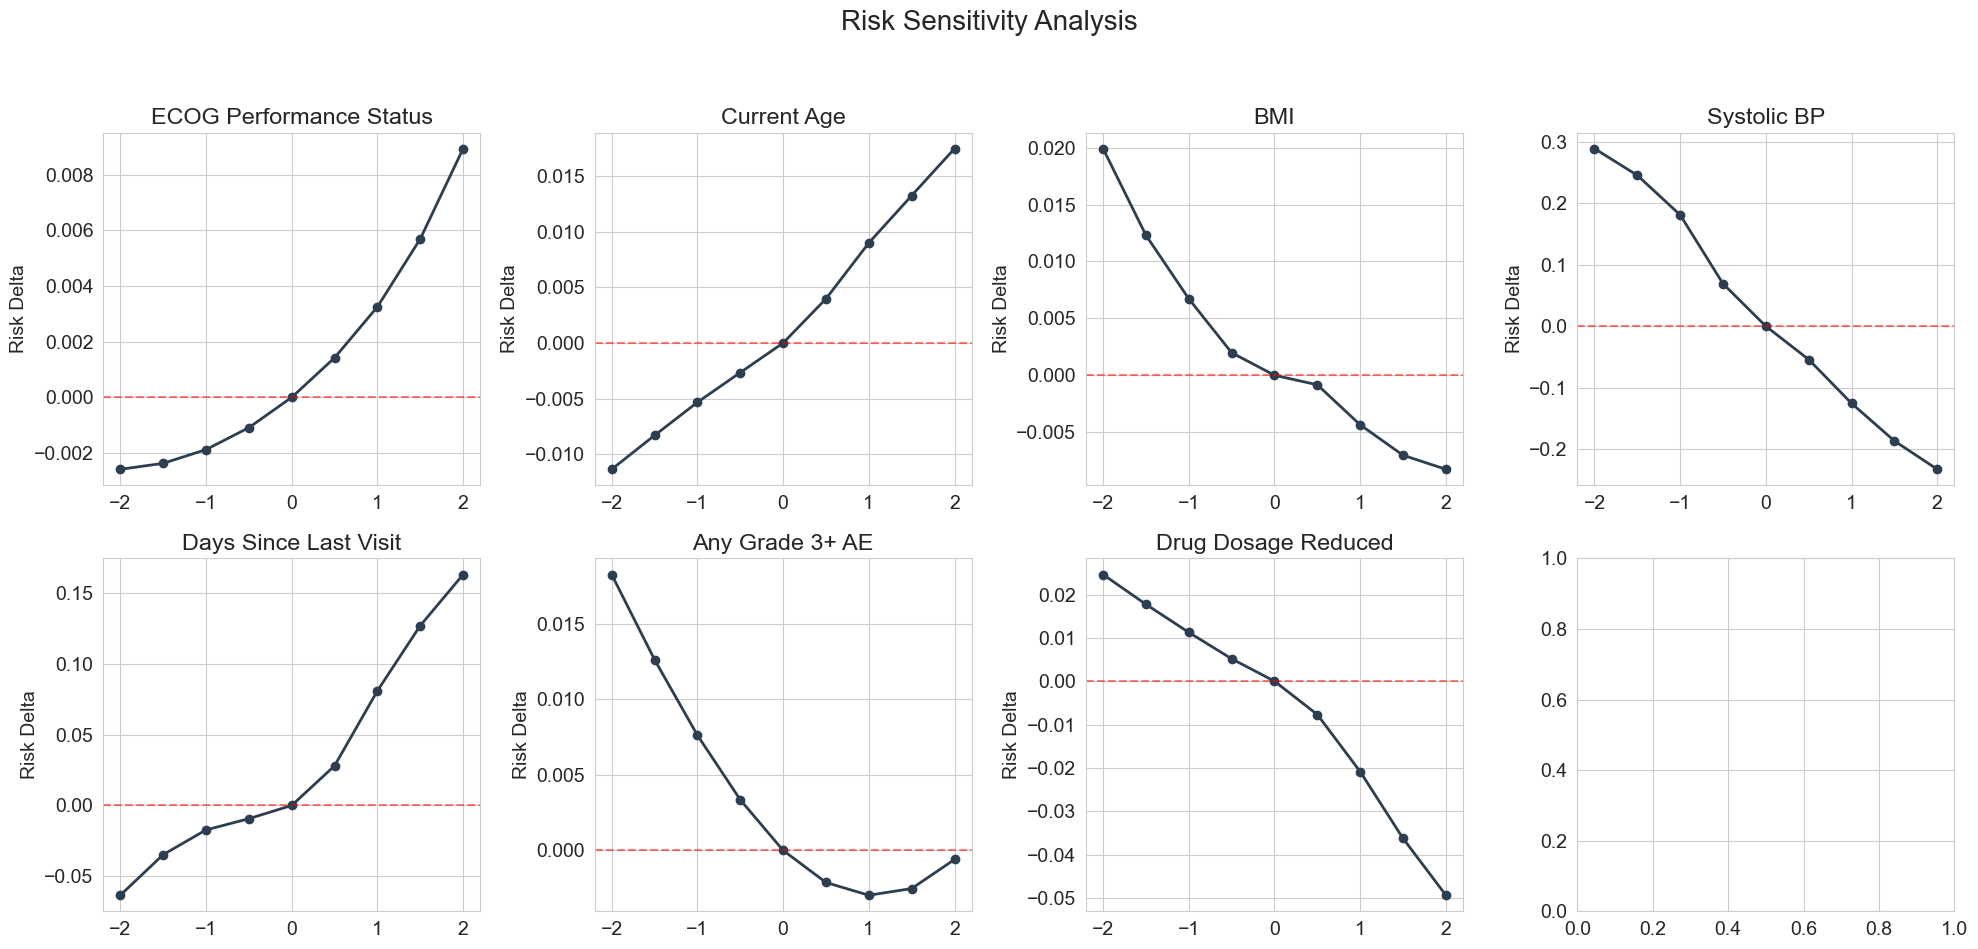

In [22]:
%load_ext autoreload
%autoreload 2

import grumodel

import pandas as pd

# 1. Load data
pcvaldata = pd.read_csv("/Users/javimencia/Desktop/HIVE Lab/Cancer Model/Main Experiment/PC002_De-id_Database 2/pcvaldata.csv")
# 2. Define features
features =  [
    'ECOGGRN', 'current_age', 'BMI', 'trxlength',
    'days_since_last_visit', 'any_grade3_plus',
    'drug_reduced'
]

internal_columns = [
    'ECOG Performance Status', 'Current Age', 'BMI', 'Systolic BP',
    'Days Since Last Visit', 'Any Grade 3+ AE', 'Drug Dosage Reduced'

]

pipeline = grumodel.SequentialSurvivalGRU(
    internal_columns,
    features,
    horizon = 180,
    sequence_length = 12
)


# 4. Run the analysis
pipeline.run_analysis(pcvaldata)
